# Proyecto Final: carrera de Especialización en Inteligencia Artificial
## Título: Modelado de ventas por Series de tiempo mediante técnicas de regresión

* Koller Tomás
* Universidad de Buenos Aires

-----

## Sobre el Dataset

En esta etapa se realizaran algunos de los puntos del enunciado, tales como:

* a) Limpieza y preparación de los datos
* b) Descripción de los datos: Describa el origen y el tipo de dato de cada uno de los atributos de la tabla.


Utilizamos un dataset sobre...

COMPLETAR CON LA DESCRIPCION GENERAL DEL DATASET 

### Realizamos un EDA sobre el dataset descripto

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder,LabelEncoder
import os
import duckdb
from prophet import Prophet
from pathlib import Path
from prophet.diagnostics import cross_validation, performance_metrics
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller

/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
DATA_DIR = os.path.expanduser('~/EspecializacionIA/Proyecto_Final/data')
DB_PATH  = Path(DATA_DIR) / 'ventas.duckdb'

print("CWD:", os.getcwd())
print("DATA_DIR:", DATA_DIR)
print("DB_PATH exists?:", DB_PATH.exists())

# Listar CSVs detectados
csvs = sorted(Path(DATA_DIR).glob("*.csv"))
print("CSV count:", len(csvs))
print("Ejemplos:", [p.name for p in csvs[:3]])


CWD: /home/v-tkoller/EspecializacionIA/Proyecto_Final/notebooks
DATA_DIR: /home/v-tkoller/EspecializacionIA/Proyecto_Final/data
DB_PATH exists?: True
CSV count: 5
Ejemplos: ['ventas_havanna_2025.csv', 'ventas_havanna_primera_2023.csv', 'ventas_havanna_primera_2024.csv']


In [3]:
con = duckdb.connect(str(DB_PATH))  # usa la DB exacta, no una relativa
print(con.execute("PRAGMA database_list").fetchdf())
print(con.execute("SHOW TABLES").fetchdf())


   seq    name                                               file
0  570  ventas  /home/v-tkoller/EspecializacionIA/Proyecto_Fin...
     name
0  ventas


In [4]:
df_ventas = pd.read_parquet("ventas.parquet")


Observamos el tipo de dato de las columnas

In [5]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4890516 entries, 0 to 4890515
Data columns (total 18 columns):
 #   Column                                  Dtype 
---  ------                                  ----- 
 0   Cantidad                                int64 
 1   Venta_Propia_Neta                       object
 2   Fecha_Documento_Factura                 object
 3   Zona                                    object
 4   Table_Source                            object
 5   Es_Mismas_Sucursales                    int64 
 6   Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano  object
 7   Venta_Propia_Neta_Actualizado_Hoy       object
 8   ID_Cliente                              int64 
 9   ID_Material                             int64 
 10  ID_Canal_Venta                          object
 11  ID_Sucursal                             object
 12  Nombre_Cliente                          object
 13  Nombre_Producto                         object
 14  Rubro                                   object
 15

In [6]:
df_ventas.head()

,Cantidad,Venta_Propia_Neta,Fecha_Documento_Factura,Zona,Table_Source,Es_Mismas_Sucursales,Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,Venta_Propia_Neta_Actualizado_Hoy,ID_Cliente,ID_Material,ID_Canal_Venta,ID_Sucursal,Nombre_Cliente,Nombre_Producto,Rubro,Categorias_SAP,Canal_Venta,Nombre_Sucursal
0,1,"1570,91",2025-01-05,Capital Federal,ventas,0,"1570,91","1822,42376175384",829,601,05,829,Florida 986,Alfajor merengue x un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
1,1,"19636,37",2025-01-05,Capital Federal,ventas,0,"19636,37","22780,2912213877",829,25,05,829,Florida 986,Alfajor 70 cacao caja x9un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
2,2,"9434,38",2025-01-05,Capital Federal,ventas,0,"9434,38","10944,8907253854",829,2573,05,829,Florida 986,Tableta choc x80g,Chocolates,TABLETAS,Locales Propios,Florida 986
3,1,"14138,18",2025-01-05,Capital Federal,ventas,0,"14138,18","16401,8022547141",829,21,05,829,Florida 986,Havannet choc caja x12un,Havannets,TRADICIONAL HAVANNETS,Locales Propios,Florida 986
4,8,"125672,72",2025-01-05,Capital Federal,ventas,0,"125672,72","145793,808131743",829,1,05,829,Florida 986,Alfajor mixto caja x 12un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986


In [7]:
df_ventas.shape

(4890516, 18)

In [8]:
df_ventas.describe()

,Cantidad,Es_Mismas_Sucursales,ID_Cliente,ID_Material
count,4.890516e+06,4.890516e+06,4.890516e+06,4.890516e+06
mean,2.736889e+01,8.695066e-01,7.376611e+03,2.853542e+05
std,3.998688e+02,3.368455e-01,1.509176e+04,2.988575e+05
min,-7.800000e+04,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00,8.340000e+02,6.960000e+02
50%,3.000000e+00,1.000000e+00,9.300000e+02,3.814000e+03
75%,8.000000e+00,1.000000e+00,9.820000e+02,6.013840e+05
max,1.664000e+05,1.000000e+00,6.048000e+04,6.131710e+05


Normalizamos los datos numericos

In [9]:
cols = [
    "Venta_Propia_Neta",
    "Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano",
    "Venta_Propia_Neta_Actualizado_Hoy"
]

def parse_num(x):
    if pd.isna(x): 
        return np.nan
    s = str(x).strip().replace('\xa0','').replace(' ', '')
    s = re.sub(r'[^\d,.\-]', '', s)  # quita símbolos raros

    has_comma = ',' in s
    has_dot   = '.' in s

    if has_comma and has_dot:
        dec = ',' if s.rfind(',') > s.rfind('.') else '.'
        thou = '.' if dec == ',' else ','
        s = s.replace(thou, '')
        s = s.replace(dec, '.')
    elif has_comma:
        s = s.replace(',', '.')
    elif s.count('.') > 1:
        s = s.replace('.', '')

    try:
        return float(s)
    except:
        return np.nan

# Aplica conversión
for c in cols:
    df_ventas[c] = df_ventas[c].apply(parse_num).astype('float64')

pd.options.display.float_format = '{:.6f}'.format

Conversión de la fecha a formato datetime

In [10]:

df_ventas["Fecha_Documento_Factura"] = pd.to_datetime(df_ventas["Fecha_Documento_Factura"], errors="coerce")

In [11]:
df_ventas.head()

,Cantidad,Venta_Propia_Neta,Fecha_Documento_Factura,Zona,Table_Source,Es_Mismas_Sucursales,Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,Venta_Propia_Neta_Actualizado_Hoy,ID_Cliente,ID_Material,ID_Canal_Venta,ID_Sucursal,Nombre_Cliente,Nombre_Producto,Rubro,Categorias_SAP,Canal_Venta,Nombre_Sucursal
0,1,1570.910000,2025-01-05,Capital Federal,ventas,0,1570.910000,1822.423762,829,601,05,829,Florida 986,Alfajor merengue x un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
1,1,19636.370000,2025-01-05,Capital Federal,ventas,0,19636.370000,22780.291221,829,25,05,829,Florida 986,Alfajor 70 cacao caja x9un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
2,2,9434.380000,2025-01-05,Capital Federal,ventas,0,9434.380000,10944.890725,829,2573,05,829,Florida 986,Tableta choc x80g,Chocolates,TABLETAS,Locales Propios,Florida 986
3,1,14138.180000,2025-01-05,Capital Federal,ventas,0,14138.180000,16401.802255,829,21,05,829,Florida 986,Havannet choc caja x12un,Havannets,TRADICIONAL HAVANNETS,Locales Propios,Florida 986
4,8,125672.720000,2025-01-05,Capital Federal,ventas,0,125672.720000,145793.808132,829,1,05,829,Florida 986,Alfajor mixto caja x 12un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986


In [12]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4890516 entries, 0 to 4890515
Data columns (total 18 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Cantidad                                int64         
 1   Venta_Propia_Neta                       float64       
 2   Fecha_Documento_Factura                 datetime64[ns]
 3   Zona                                    object        
 4   Table_Source                            object        
 5   Es_Mismas_Sucursales                    int64         
 6   Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano  float64       
 7   Venta_Propia_Neta_Actualizado_Hoy       float64       
 8   ID_Cliente                              int64         
 9   ID_Material                             int64         
 10  ID_Canal_Venta                          object        
 11  ID_Sucursal                             object        
 12  Nombre_Cliente                          ob

### Hacemos un analisis de elementos duplicados y nulos

In [13]:
# Cantidad de duplicados
num_duplicados = df_ventas.duplicated().sum()
print(f"Total de filas duplicadas: {num_duplicados}")

# Mostrar las primeras filas duplicadas
df_duplicados = df_ventas[df_ventas.duplicated()]
print(df_duplicados.head(10))


Total de filas duplicadas: 1018
         Cantidad  Venta_Propia_Neta Fecha_Documento_Factura             Zona  \
1953579         1      -96150.980000              2023-06-30  Capital Federal   
1953594         1     -168015.180000              2023-06-30      Gran Bs.As.   
1953607         1     -128422.950000              2023-06-30      Gran Bs.As.   
1953612         1      -95439.370000              2023-06-30      Gran Bs.As.   
1953627         1     -175639.530000              2023-06-30  Capital Federal   
1953639         1     -211999.770000              2023-06-30  Capital Federal   
1953665         1     -102715.610000              2023-06-30  Capital Federal   
1953680         1      -74933.280000              2023-06-30         Interior   
1953685         1     -174163.520000              2023-06-30      Gran Bs.As.   
1953727         1     -150915.990000              2023-06-30  Capital Federal   

        Table_Source  Es_Mismas_Sucursales  \
1953579       ajuste          

In [14]:
# Copia de trabajo y normalización de nombres
df = df_ventas.copy()
df.columns = df.columns.str.strip()

# Normalización de Table_Source para filtrar mayúsculas/espacios
ts_norm = df["Table_Source"].astype(str).str.strip().str.lower()

# Identificar registros que pertenecen a grupos duplicados
dup_mask_all = df.duplicated(keep=False)
dup_df = df.loc[dup_mask_all].copy()

print("Total de filas en grupos duplicados (incluye primeras y repetidas):", dup_df.shape[0])

# Solo duplicados
dup_mask_only_repeated = df.duplicated(keep='first')
print("Total de filas duplicadas (conteo original):", dup_mask_only_repeated.sum())

# Dentro de los duplicados, filtramos solo con Table_Source == 'ajuste' 
dup_df_ts_ok = dup_df[dup_df["Table_Source"].astype(str).str.strip().str.lower() == "ajuste"].copy()
print("Duplicados con Table_Source == 'ajuste':", dup_df_ts_ok.shape[0])

# Deduplicar ese subconjunto filtrado (por todas las columnas) ---
dup_df_ts_ok_unique = dup_df_ts_ok.drop_duplicates(keep="first").copy()
print("Duplicados 'ajuste' tras deduplicar (únicos):", dup_df_ts_ok_unique.shape[0])

# Remover del dataset original todos los registros que pertenecen a grupos duplicados 
df_base = df.loc[~dup_mask_all].copy()
print("Filas en el dataset sin ningún grupo duplicado:", df_base.shape[0])

# Reincorporar los 'ajuste' únicos
df_final = pd.concat([df_base, dup_df_ts_ok_unique], ignore_index=True)

# Reset index y chequeos finales
df_ventas = df_final.reset_index(drop=True)

print("Filas finales:", df_ventas.shape[0])

# Chequeo de que no hayamos reintroducido duplicados totales
total_dups_final = df_ventas.duplicated(keep=False).sum()
print("Filas en grupos duplicados en df_final:", total_dups_final)


Total de filas en grupos duplicados (incluye primeras y repetidas): 2036
Total de filas duplicadas (conteo original): 1018
Duplicados con Table_Source == 'ajuste': 304
Duplicados 'ajuste' tras deduplicar (únicos): 152
Filas en el dataset sin ningún grupo duplicado: 4888480
Filas finales: 4888632
Filas en grupos duplicados en df_final: 0


Realizamos esta eliminacion debido a Tiendas que han cerrado y no se consderan en el análisis

In [15]:
# Eliminamos filas cuyo Nombre_Cliente o Nombre_Sucursal empiecen con 'ZZ'
mask_drop = (
    df_ventas["Nombre_Cliente"].astype(str).str.startswith("ZZ") |
    df_ventas["Nombre_Sucursal"].astype(str).str.startswith("ZZ")
)

df_ventas = df_ventas.loc[~mask_drop].reset_index(drop=True)

print("Filas eliminadas:", mask_drop.sum())
print("Filas finales:", len(df_ventas))


Filas eliminadas: 321502
Filas finales: 4567130


In [16]:
# Chequear nulos
print(df_ventas.isnull().sum())


Cantidad                                     0
Venta_Propia_Neta                         2334
Fecha_Documento_Factura                      0
Zona                                         0
Table_Source                                 0
Es_Mismas_Sucursales                         0
Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano    2334
Venta_Propia_Neta_Actualizado_Hoy         2334
ID_Cliente                                   0
ID_Material                                  0
ID_Canal_Venta                               0
ID_Sucursal                                  0
Nombre_Cliente                               0
Nombre_Producto                              0
Rubro                                        0
Categorias_SAP                               0
Canal_Venta                                  0
Nombre_Sucursal                              0
dtype: int64


Comprobamos que no hay nulos en la columna cantidad

In [17]:
df_ventas[df_ventas['Cantidad'].isna()].head()


,Cantidad,Venta_Propia_Neta,Fecha_Documento_Factura,Zona,Table_Source,Es_Mismas_Sucursales,Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,Venta_Propia_Neta_Actualizado_Hoy,ID_Cliente,ID_Material,ID_Canal_Venta,ID_Sucursal,Nombre_Cliente,Nombre_Producto,Rubro,Categorias_SAP,Canal_Venta,Nombre_Sucursal


In [18]:
df_nulos = df_ventas[df_ventas['Cantidad'].isna()]

conteo_por_producto = (
    df_nulos.groupby('Nombre_Producto')
    .size()
    .reset_index(name='Cantidad_Registros_Nulos')
    .sort_values(by='Cantidad_Registros_Nulos', ascending=False)
)

print(conteo_por_producto)


Empty DataFrame
Columns: [Nombre_Producto, Cantidad_Registros_Nulos]
Index: []


In [19]:
missing_data = df_ventas.isnull().sum().to_frame(name='nulos')
missing_data['porcentaje'] = 100 * missing_data['nulos'] / len(df_ventas)
missing_data = missing_data[missing_data['nulos'] > 0].sort_values(by='porcentaje', ascending=False)
missing_data

,nulos,porcentaje
Venta_Propia_Neta,2334,0.051104
Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,2334,0.051104
Venta_Propia_Neta_Actualizado_Hoy,2334,0.051104


In [20]:
df_ventas = df_ventas.dropna(subset=['Venta_Propia_Neta'])

In [21]:
df_ventas=df_ventas.drop([ 'ID_Material','ID_Cliente','ID_Canal_Venta','ID_Sucursal'],axis=1)

In [22]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4564796 entries, 0 to 4567129
Data columns (total 14 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Cantidad                                int64         
 1   Venta_Propia_Neta                       float64       
 2   Fecha_Documento_Factura                 datetime64[ns]
 3   Zona                                    object        
 4   Table_Source                            object        
 5   Es_Mismas_Sucursales                    int64         
 6   Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano  float64       
 7   Venta_Propia_Neta_Actualizado_Hoy       float64       
 8   Nombre_Cliente                          object        
 9   Nombre_Producto                         object        
 10  Rubro                                   object        
 11  Categorias_SAP                          object        
 12  Canal_Venta                             object 

In [23]:
df_ventas.head()

,Cantidad,Venta_Propia_Neta,Fecha_Documento_Factura,Zona,Table_Source,Es_Mismas_Sucursales,Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,Venta_Propia_Neta_Actualizado_Hoy,Nombre_Cliente,Nombre_Producto,Rubro,Categorias_SAP,Canal_Venta,Nombre_Sucursal
0,1,1570.910000,2025-01-05,Capital Federal,ventas,0,1570.910000,1822.423762,Florida 986,Alfajor merengue x un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
1,1,19636.370000,2025-01-05,Capital Federal,ventas,0,19636.370000,22780.291221,Florida 986,Alfajor 70 cacao caja x9un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986
2,2,9434.380000,2025-01-05,Capital Federal,ventas,0,9434.380000,10944.890725,Florida 986,Tableta choc x80g,Chocolates,TABLETAS,Locales Propios,Florida 986
3,1,14138.180000,2025-01-05,Capital Federal,ventas,0,14138.180000,16401.802255,Florida 986,Havannet choc caja x12un,Havannets,TRADICIONAL HAVANNETS,Locales Propios,Florida 986
4,8,125672.720000,2025-01-05,Capital Federal,ventas,0,125672.720000,145793.808132,Florida 986,Alfajor mixto caja x 12un,Alfajores,TRADICIONAL ALFAJORES,Locales Propios,Florida 986


In [24]:
print(df_ventas["Cantidad"].describe())

count   4564796.000000
mean         28.560644
std         413.361570
min      -78000.000000
25%           1.000000
50%           3.000000
75%           9.000000
max      166400.000000
Name: Cantidad, dtype: float64


In [25]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, snk=False):
    skewness = (data[column].dropna()).skew()
    kurtosis = (data[column].dropna()).kurt()
    media = (data[column].dropna()).mean()
    var = (data[column].dropna()).var()
    std = (data[column].dropna()).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column].dropna(), bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
    plt.axvline(media, color='red', linestyle='--', label='Media')
    if mvd:
        plt.figtext(0.15, 0.8, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var: {var:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std: {std:.2f}', fontsize=10, color='red')
    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()

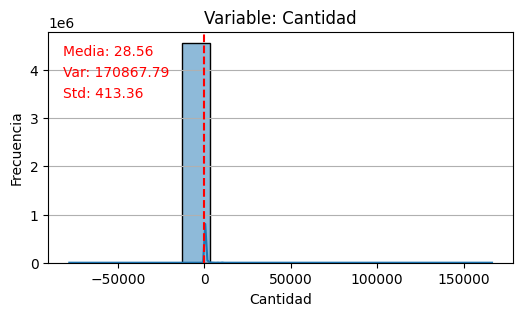

In [26]:
plot_histograma(df_ventas, 'Cantidad')

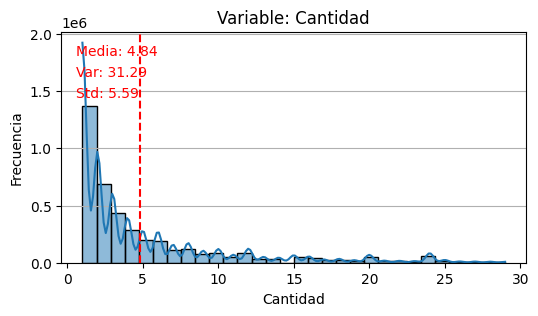

In [27]:
percentil_95 = df_ventas['Cantidad'].quantile(0.90)
percentil_05 = df_ventas['Cantidad'].quantile(0.05)

# Filtrar el DataFrame
df_filtrado = df_ventas[
    (df_ventas['Cantidad'] >= percentil_05) & 
    (df_ventas['Cantidad'] <= percentil_95)
]


# Graficar histograma con los datos filtrados
plot_histograma(df_filtrado, 'Cantidad', bins=30)

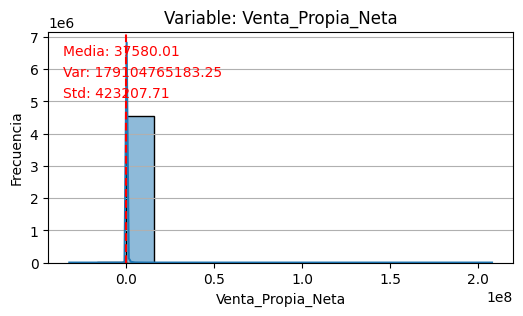

In [28]:
plot_histograma(df_ventas, 'Venta_Propia_Neta')

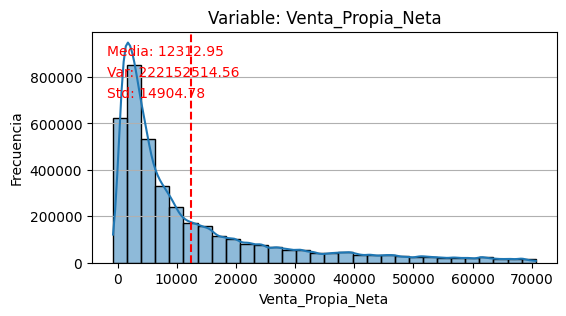

In [29]:
percentil_95 = df_ventas['Venta_Propia_Neta'].quantile(0.90)
percentil_05 = df_ventas['Venta_Propia_Neta'].quantile(0.05)

# Filtrar el DataFrame
df_filtrado = df_ventas[
    (df_ventas['Venta_Propia_Neta'] >= percentil_05) & 
    (df_ventas['Venta_Propia_Neta'] <= percentil_95)
]


# Graficar histograma con los datos filtrados
plot_histograma(df_filtrado, 'Venta_Propia_Neta', bins=30)

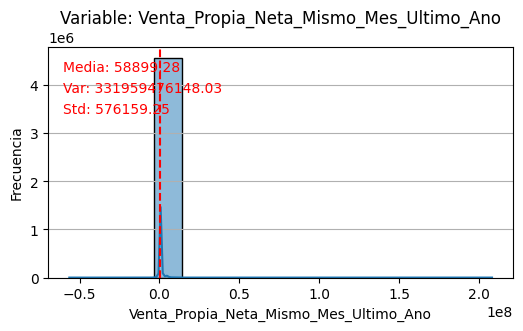

In [30]:
plot_histograma(df_ventas, 'Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano') 

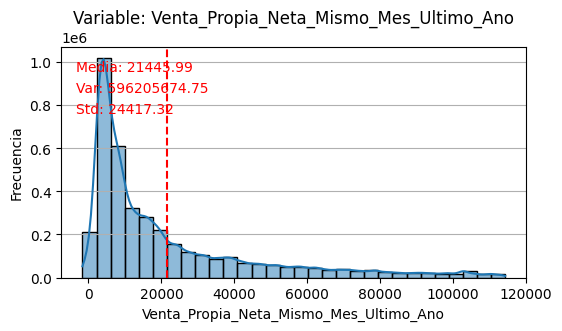

In [31]:
percentil_95 = df_ventas['Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano'].quantile(0.90)
percentil_05 = df_ventas['Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano'].quantile(0.05)

# Filtrar el DataFrame
df_filtrado = df_ventas[
    (df_ventas['Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano'] >= percentil_05) & 
    (df_ventas['Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano'] <= percentil_95)
]

# Graficar histograma con los datos filtrados
plot_histograma(df_filtrado, 'Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano', bins=30)

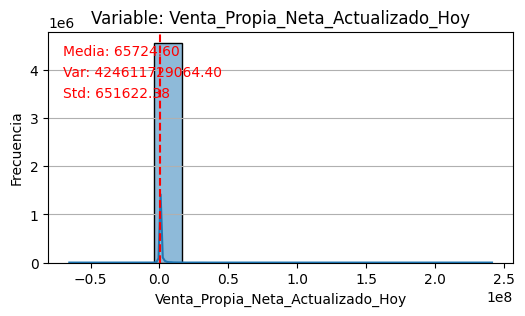

In [32]:
plot_histograma(df_ventas, 'Venta_Propia_Neta_Actualizado_Hoy')     

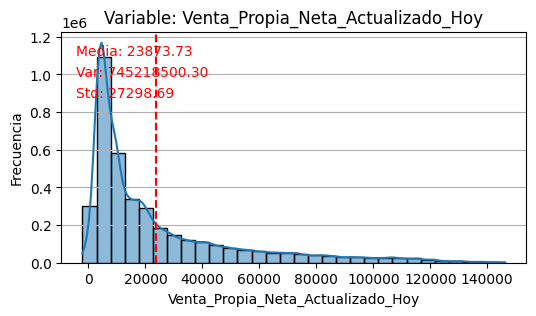

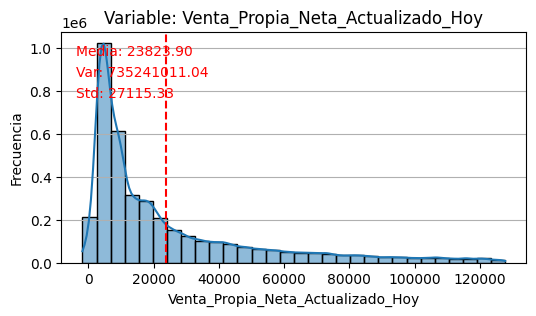

In [33]:
# Graficar histograma con los datos filtrados
plot_histograma(df_filtrado, 'Venta_Propia_Neta_Actualizado_Hoy', bins=30)

percentil_95 = df_ventas['Venta_Propia_Neta_Actualizado_Hoy'].quantile(0.90)
percentil_05 = df_ventas['Venta_Propia_Neta_Actualizado_Hoy'].quantile(0.05)

# Filtrar el DataFrame
df_filtrado = df_ventas[
    (df_ventas['Venta_Propia_Neta_Actualizado_Hoy'] >= percentil_05) & 
    (df_ventas['Venta_Propia_Neta_Actualizado_Hoy'] <= percentil_95)
]

# Graficar histograma con los datos filtrados
plot_histograma(df_filtrado, 'Venta_Propia_Neta_Actualizado_Hoy', bins=30)

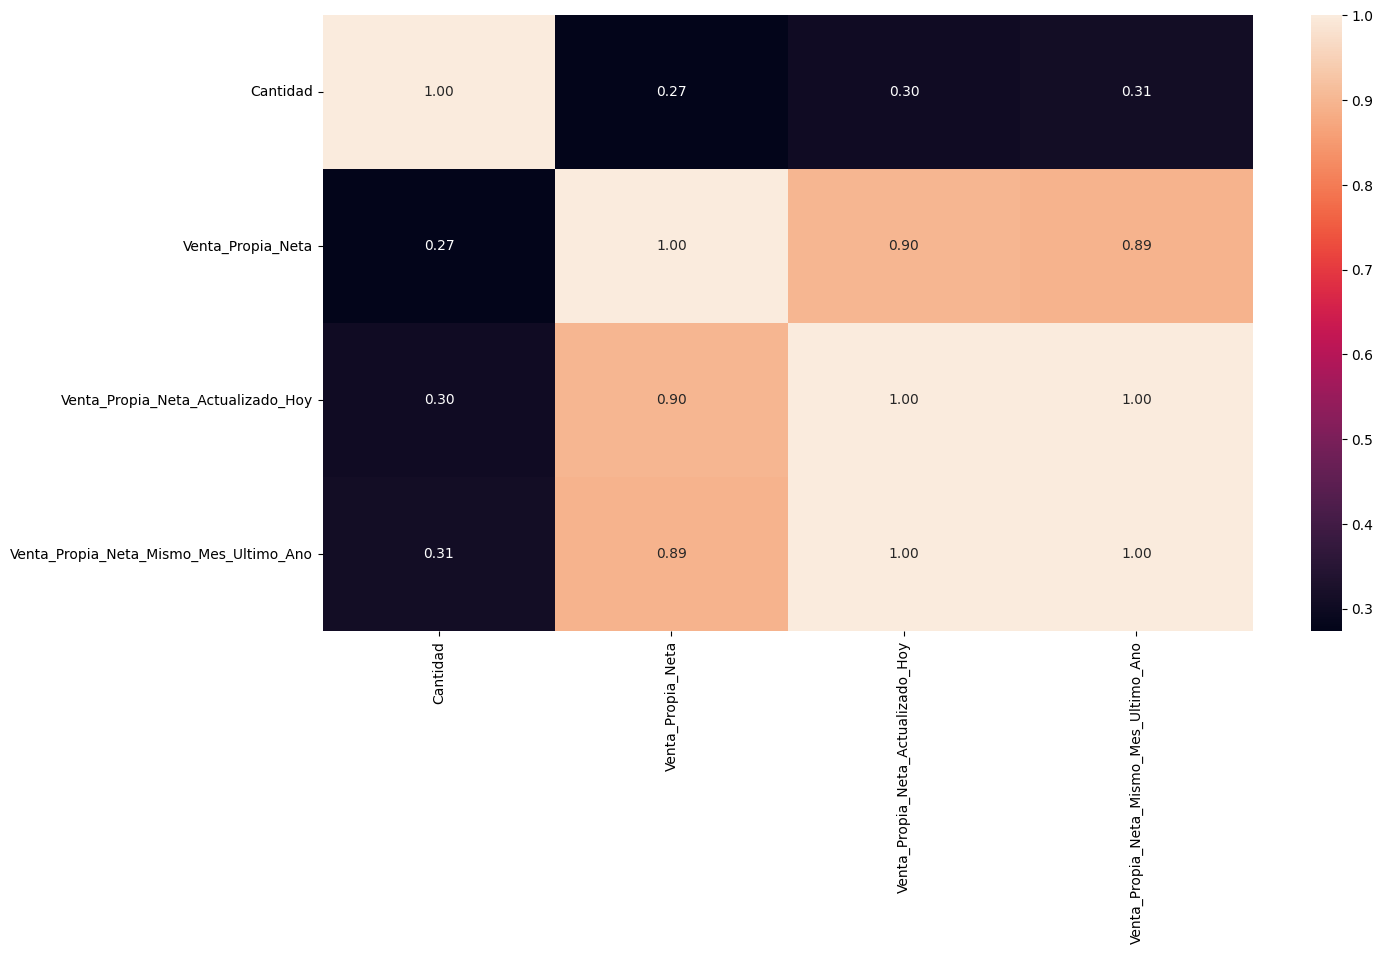

In [34]:
subset_columnas = ['Cantidad','Venta_Propia_Neta', 'Venta_Propia_Neta_Actualizado_Hoy', 'Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano']


sub_df = df_ventas[subset_columnas]

correlacion_matrix = sub_df.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(correlacion_matrix, annot=True, cmap='rocket', annot_kws={"size": 10}, fmt=".2f", cbar=True)
plt.show()

In [35]:
df_numbers=df_ventas[['Cantidad','Venta_Propia_Neta', 'Venta_Propia_Neta_Actualizado_Hoy', 'Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano']]
df_numbers.dtypes

Cantidad                                    int64
Venta_Propia_Neta                         float64
Venta_Propia_Neta_Actualizado_Hoy         float64
Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano    float64
dtype: object

In [36]:
cols = ['Cantidad']

outliers = pd.DataFrame()

for col in cols:
    Q1 = df_ventas[col].quantile(0.25)
    Q3 = df_ventas[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    mask = (df_ventas[col] < lower) | (df_ventas[col] > upper)
    outliers = pd.concat([outliers, df_ventas[mask]], axis=0)

# Eliminar duplicados si el mismo registro es outlier en varias columnas
outliers = outliers.drop_duplicates()


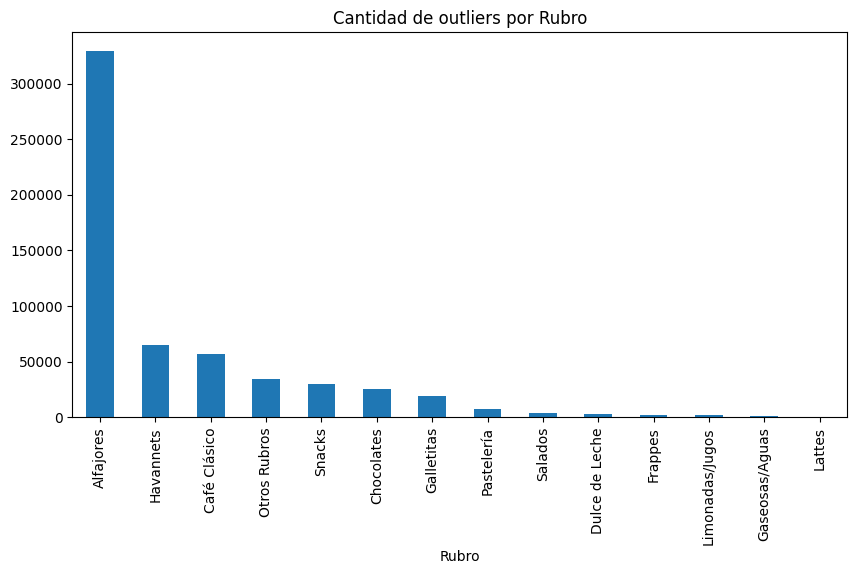

In [37]:
# Conteo de outliers por tipo de producto
outlier_summary = outliers.groupby(['Rubro','Categorias_SAP','Nombre_Producto']).size().reset_index(name='Cantidad_Outliers')

# Ordenar por mayor cantidad de outliers
outlier_summary = outlier_summary.sort_values(by='Cantidad_Outliers', ascending=False)

import matplotlib.pyplot as plt

# Visualización por rubro
outlier_summary.groupby('Rubro')['Cantidad_Outliers'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Cantidad de outliers por Rubro")
plt.show()


In [38]:
df_otros_rubros=df_ventas[df_ventas['Rubro'] == 'Otros Rubros'] 
df_otros_rubros.head()

,Cantidad,Venta_Propia_Neta,Fecha_Documento_Factura,Zona,Table_Source,Es_Mismas_Sucursales,Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano,Venta_Propia_Neta_Actualizado_Hoy,Nombre_Cliente,Nombre_Producto,Rubro,Categorias_SAP,Canal_Venta,Nombre_Sucursal
7,1,4717.190000,2025-01-05,Capital Federal,ventas,0,4717.190000,5472.445363,Florida 986,Paila navidad almendras x100g,Otros Rubros,PAILAS,Locales Propios,Florida 986
31,1,-267.050000,2025-01-05,Capital Federal,ventas,0,-267.050000,-309.806587,Florida 986,Descuentos Empleados,Otros Rubros,DESCUENTOS,Locales Propios,Florida 986
44,4,-2372.070000,2025-01-24,Capital Federal,ventas,0,-2372.070000,-2751.855124,Florida 986,Descuentos Empleados,Otros Rubros,DESCUENTOS,Locales Propios,Florida 986
65,1,-329.890000,2025-01-24,Capital Federal,ventas,0,-329.890000,-382.707714,Florida 986,Socios Sport Club- 15% de descuento,Otros Rubros,DESCUENTOS,Locales Propios,Florida 986
112,1,-1932.220000,2025-06-12,Capital Federal,ventas,1,-1932.220000,-1990.621349,Florida 986,Descuentos Empleados,Otros Rubros,DESCUENTOS,Locales Propios,Florida 986


In [39]:
df_otros_rubros_grouped = (
    df_otros_rubros
    .groupby('Nombre_Producto')
    .size()  # cuenta las filas
    .reset_index(name='Cantidad_Registros')
    .sort_values(by='Cantidad_Registros', ascending=False)
)

print(df_otros_rubros_grouped.head())


                      Nombre_Producto  Cantidad_Registros
84               Descuentos Empleados               26495
82       Descuento hvna salados pleno               24942
78                 Descuento Shopping               11011
71   Descuento $100 vaso reutilizable               10449
208           Voucher Digital Havanna                9586


In [40]:
df_ventas.drop(df_ventas[df_ventas['Rubro'] == 'Otros Rubros'].index, inplace=True)

In [41]:
agrupado_canal = (
    df_ventas
    .groupby('Canal_Venta')['Cantidad']
    .sum()
    .reset_index()
)

# Calcular porcentaje
total = agrupado_canal['Cantidad'].sum()
agrupado_canal['Porcentaje'] = 100 * agrupado_canal['Cantidad'] / total

# Ordenar de mayor a menor
agrupado_canal = agrupado_canal.sort_values(by='Cantidad', ascending=False)

print(agrupado_canal)


         Canal_Venta  Cantidad  Porcentaje
3        Franquicias  74982701   64.908127
4    Locales Propios  21980243   19.027007
2           Exterior  12175611   10.539712
6  Ventas Especiales   4858909    4.206073
0         Aeropuerto   1118242    0.967997
5      Supermercados    384406    0.332758
1          Ecommerce     21171    0.018326


In [42]:
df_ventas.drop(df_ventas[df_ventas['Rubro'] == 'Otros Rubros'].index, inplace=True)

In [43]:
df_ventas = df_ventas[df_ventas['Canal_Venta'].isin(['Franquicias', 'Locales Propios'])]


In [44]:
print("Filas finales:", len(df_ventas))

Filas finales: 4310406


       Canal_Venta  Cantidad_Outliers
0      Franquicias             409046
1  Locales Propios             200983


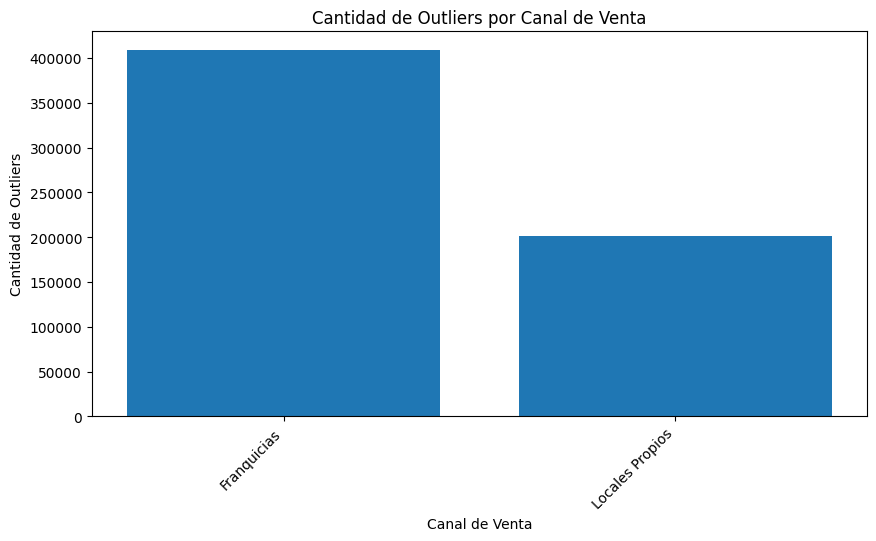

In [45]:
# Columnas numéricas donde buscamos outliers
cols = ['Cantidad']

outliers = pd.DataFrame()

for col in cols:
    Q1 = df_ventas[col].quantile(0.25)
    Q3 = df_ventas[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    mask = (df_ventas[col] < lower) | (df_ventas[col] > upper)
    outliers = pd.concat([outliers, df_ventas[mask]], axis=0)

# Eliminar duplicados si el mismo registro es outlier en varias columnas
outliers = outliers.drop_duplicates()

# 🔹 Resumen agrupado por Canal_Venta
outlier_summary_canal = (
    outliers.groupby('Canal_Venta')
            .size()
            .reset_index(name='Cantidad_Outliers')
            .sort_values(by='Cantidad_Outliers', ascending=False)
)

print(outlier_summary_canal)

# 🔹 Gráfico de barras
plt.figure(figsize=(10,5))
plt.bar(outlier_summary_canal['Canal_Venta'], outlier_summary_canal['Cantidad_Outliers'])
plt.xticks(rotation=45, ha='right')
plt.title("Cantidad de Outliers por Canal de Venta")
plt.ylabel("Cantidad de Outliers")
plt.xlabel("Canal de Venta")
plt.show()
                

### Análisis de outliers, top por categorías

### Por tipo de producto

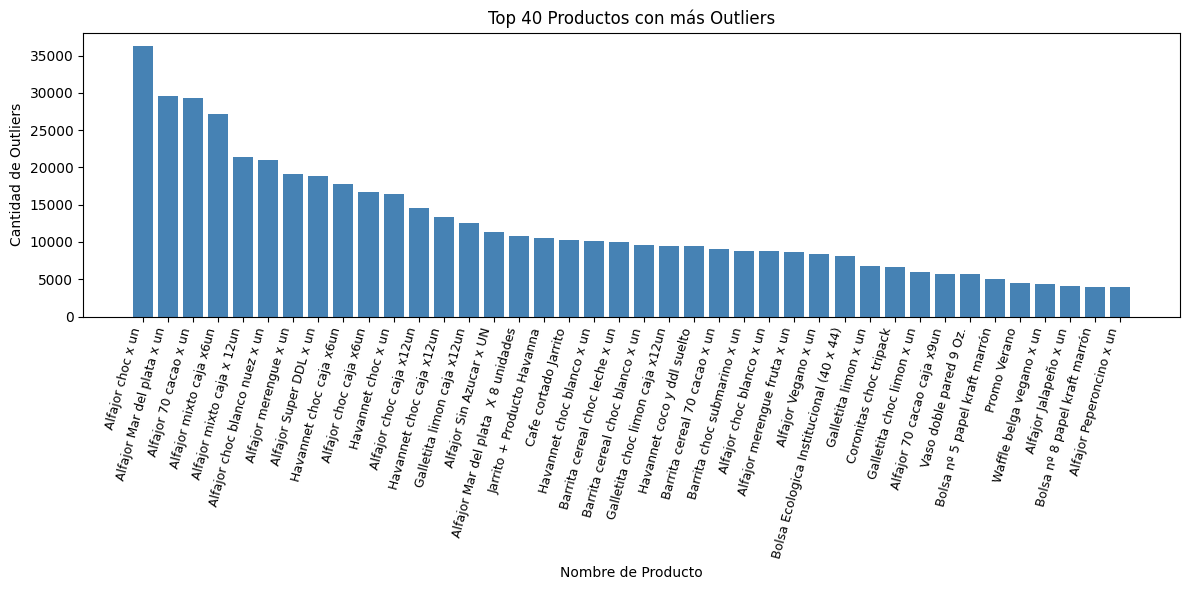

In [46]:
# Columnas numéricas donde buscamos outliers
cols = ['Cantidad']

outliers = pd.DataFrame()

for col in cols:
    Q1 = df_ventas[col].quantile(0.25)
    Q3 = df_ventas[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    mask = (df_ventas[col] < lower) | (df_ventas[col] > upper)
    outliers = pd.concat([outliers, df_ventas[mask]], axis=0)

# Eliminar duplicados si el mismo registro es outlier en varias columnas
outliers = outliers.drop_duplicates()

# 🔹 Resumen agrupado por Producto
outlier_summary_producto = (
    outliers.groupby('Nombre_Producto')
            .size()
            .reset_index(name='Cantidad_Outliers')
            .sort_values(by='Cantidad_Outliers', ascending=False)
)

# 🔹 Quedarse solo con los 40 productos con más outliers
top_n = 40
top_outliers = outlier_summary_producto.head(top_n)

# 🔹 Gráfico de barras
plt.figure(figsize=(12,6))
plt.bar(top_outliers['Nombre_Producto'], top_outliers['Cantidad_Outliers'], color='steelblue')
plt.xticks(rotation=75, ha='right', fontsize=9)
plt.title(f"Top {top_n} Productos con más Outliers")
plt.ylabel("Cantidad de Outliers")
plt.xlabel("Nombre de Producto")
plt.tight_layout()
plt.show()    

### Por sucursal

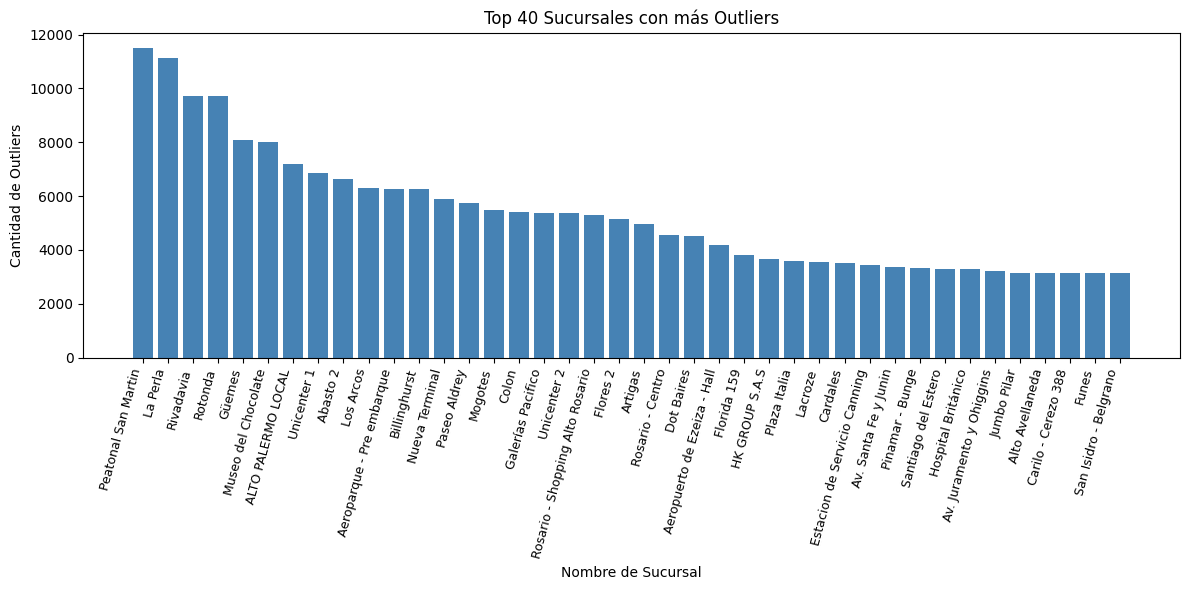

In [47]:
# Columnas numéricas donde buscamos outliers
cols = ['Cantidad']

outliers = pd.DataFrame()

for col in cols:
    Q1 = df_ventas[col].quantile(0.25)
    Q3 = df_ventas[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    mask = (df_ventas[col] < lower) | (df_ventas[col] > upper)
    outliers = pd.concat([outliers, df_ventas[mask]], axis=0)

# Eliminar duplicados si el mismo registro es outlier en varias columnas
outliers = outliers.drop_duplicates()

# 🔹 Resumen agrupado por Sucursal
outlier_summary_sucursal = (
    outliers.groupby('Nombre_Sucursal')
            .size()
            .reset_index(name='Cantidad_Outliers')
            .sort_values(by='Cantidad_Outliers', ascending=False)
)

# 🔹 Quedarse solo con las 40 sucursales con más outliers
top_n = 40
top_outliers = outlier_summary_sucursal.head(top_n)

# 🔹 Gráfico de barras
plt.figure(figsize=(12,6))
plt.bar(top_outliers['Nombre_Sucursal'], top_outliers['Cantidad_Outliers'], color='steelblue')
plt.xticks(rotation=75, ha='right', fontsize=9)
plt.title(f"Top {top_n} Sucursales con más Outliers")
plt.ylabel("Cantidad de Outliers")
plt.xlabel("Nombre de Sucursal")
plt.tight_layout()
plt.show()


In [48]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4310406 entries, 0 to 4565349
Data columns (total 14 columns):
 #   Column                                  Dtype         
---  ------                                  -----         
 0   Cantidad                                int64         
 1   Venta_Propia_Neta                       float64       
 2   Fecha_Documento_Factura                 datetime64[ns]
 3   Zona                                    object        
 4   Table_Source                            object        
 5   Es_Mismas_Sucursales                    int64         
 6   Venta_Propia_Neta_Mismo_Mes_Ultimo_Ano  float64       
 7   Venta_Propia_Neta_Actualizado_Hoy       float64       
 8   Nombre_Cliente                          object        
 9   Nombre_Producto                         object        
 10  Rubro                                   object        
 11  Categorias_SAP                          object        
 12  Canal_Venta                             object 

Observamos el grafico de cantidad de ventas por dia

<Axes: xlabel='Fecha_Documento_Factura'>

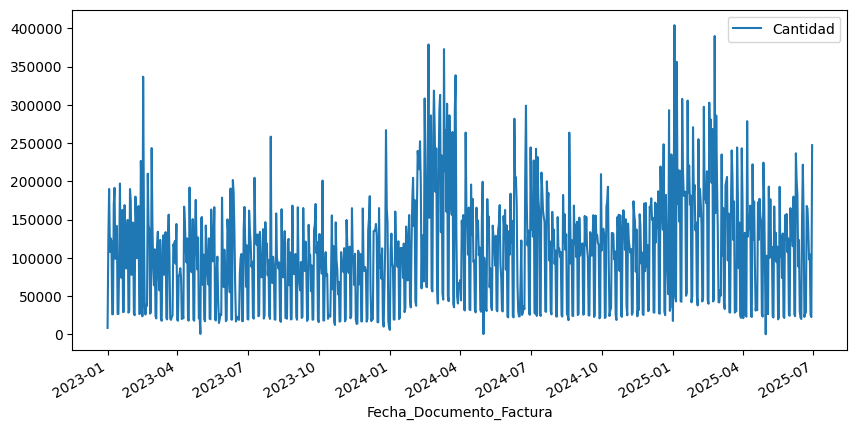

In [49]:
ventas_diarias = (df_ventas
          .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad'].sum()
          .sort_values('Fecha_Documento_Factura'))
ventas_diarias.plot(x='Fecha_Documento_Factura', y='Cantidad', figsize=(10,5))

Observamos el grafico de cantidad de ventas por dia para el canal 'franquicia'

<Axes: title={'center': 'Ventas diarias - Canal Franquicia'}, xlabel='Fecha_Documento_Factura'>

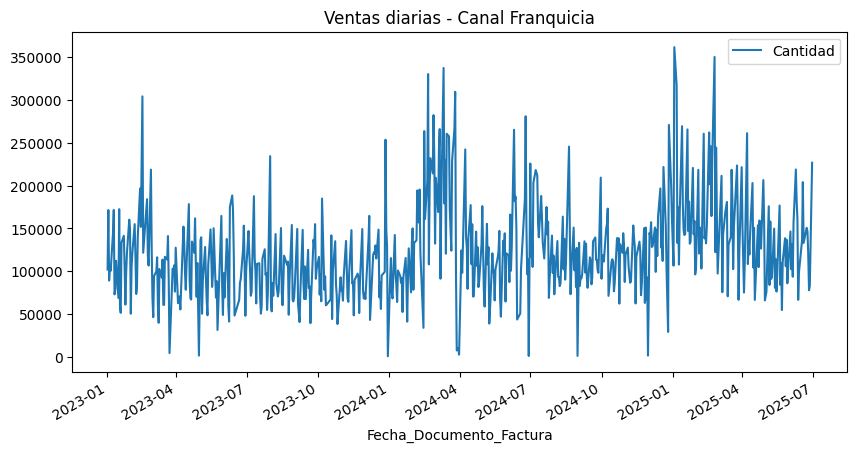

In [50]:
# Filtro
df_franq = df_ventas[df_ventas['Canal_Venta'] == 'Franquicias']

# Suma diaria y orden por fecha
ventas_diarias_franq = (df_franq
    .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad']
    .sum()
    .sort_values('Fecha_Documento_Factura')
)

# Gráfico (una sola línea con subidas/bajadas día a día)
ventas_diarias_franq.plot(
    x='Fecha_Documento_Factura',
    y='Cantidad',
    figsize=(10,5),
    title='Ventas diarias - Canal Franquicia'
)

<Axes: title={'center': 'Ventas - Canal Franquicia (2023)'}, xlabel='Fecha_Documento_Factura'>

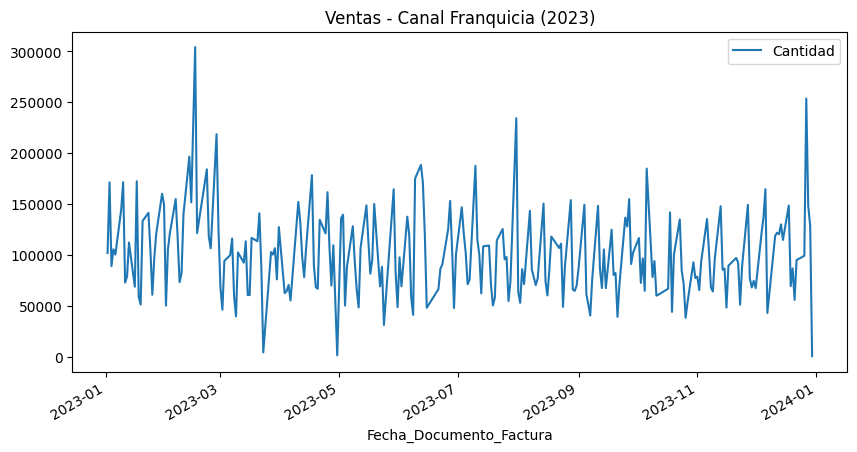

In [51]:

# Filtro
df_franq_2023 = df_ventas[(df_ventas['Canal_Venta'] == 'Franquicias') &
    (df_ventas['Fecha_Documento_Factura'].dt.year == 2023)]

# Suma diaria y orden por fecha
ventas_diarias_franq_2023 = (df_franq_2023
    .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad']
    .sum()
    .sort_values('Fecha_Documento_Factura')
)

# Gráfico (una sola línea con subidas/bajadas día a día)
ventas_diarias_franq_2023.plot(
    x='Fecha_Documento_Factura',
    y='Cantidad',
    figsize=(10,5),
    title='Ventas - Canal Franquicia (2023)'
)


<Axes: title={'center': 'Ventas Diarias - Franquicias (Dic 2023)'}, xlabel='Fecha_Documento_Factura'>

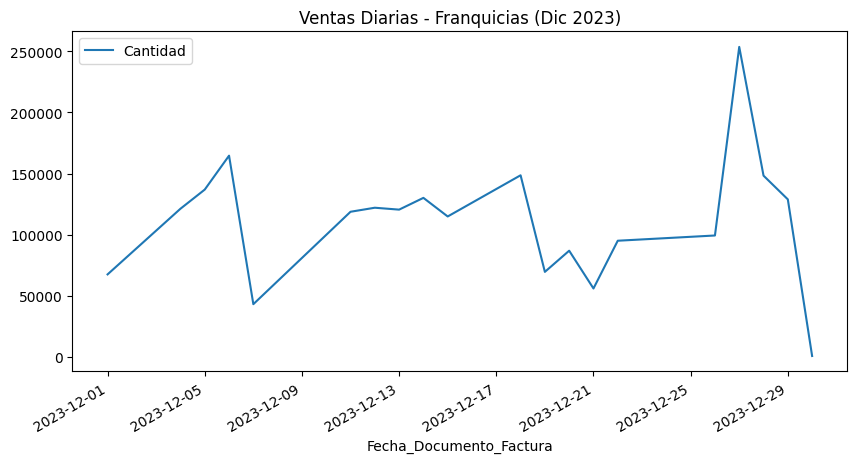

In [52]:
# Filtro del mes
df_dec = df_ventas[
    (df_ventas['Canal_Venta'] == 'Franquicias') &
    (df_ventas['Fecha_Documento_Factura'].dt.year == 2023) &
    (df_ventas['Fecha_Documento_Factura'].dt.month == 12)
].copy()


# Totales por día (convertimos a fecha sin hora) y ordenamos
ventas_diarias_dic_2023 = (df_dec
          .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad'].sum()
          .sort_values('Fecha_Documento_Factura'))


# Plot acumulado (una sola línea)
ventas_diarias_dic_2023.plot(
    x='Fecha_Documento_Factura', y='Cantidad', figsize=(10,5),
    title='Ventas Diarias - Franquicias (Dic 2023)'
)


<Axes: title={'center': 'Ventas diarias - Canal Locales Propios'}, xlabel='Fecha_Documento_Factura'>

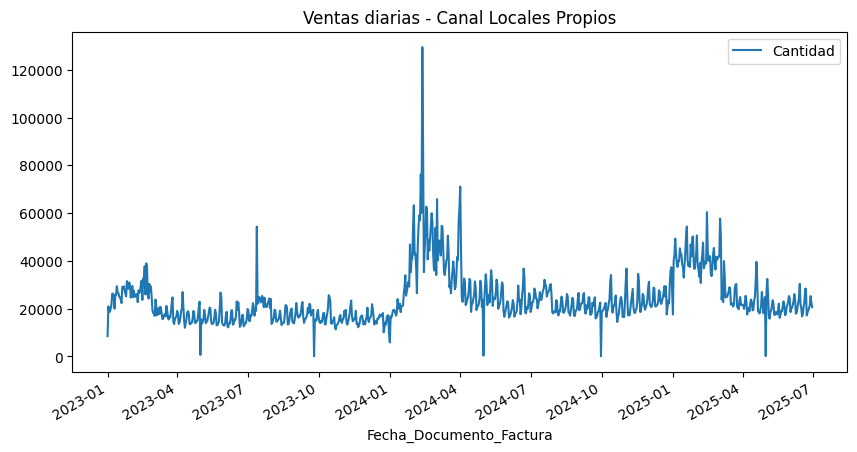

In [53]:
# Filtro
df_locales_propios = df_ventas[df_ventas['Canal_Venta'] == 'Locales Propios']

# Suma diaria y orden por fecha
ventas_diarias_locales_propios = (df_locales_propios
    .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad']
    .sum()
    .sort_values('Fecha_Documento_Factura')
)

# Gráfico (una sola línea con subidas/bajadas día a día)
ventas_diarias_locales_propios.plot(
    x='Fecha_Documento_Factura',
    y='Cantidad',
    figsize=(10,5),
    title='Ventas diarias - Canal Locales Propios'
)

<Axes: title={'center': 'Ventas - Canal Locales Propios (2023)'}, xlabel='Fecha_Documento_Factura'>

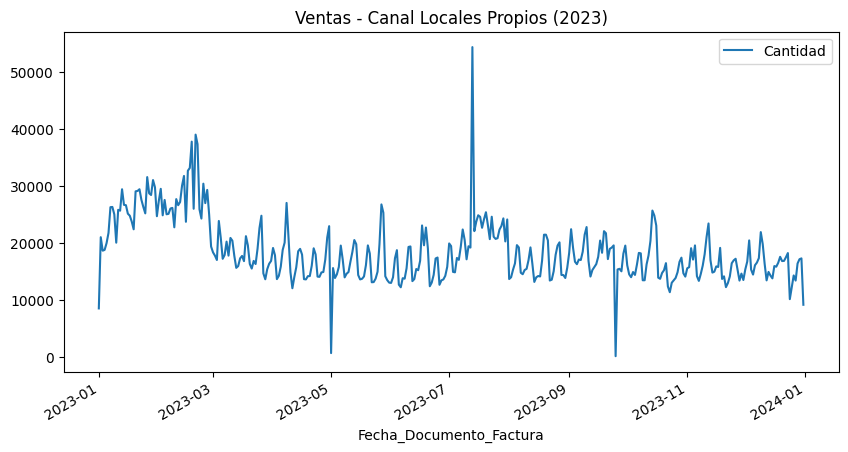

In [54]:
# Filtro
df_locales_propios_2023 = df_ventas[(df_ventas['Canal_Venta'] == 'Locales Propios') &
    (df_ventas['Fecha_Documento_Factura'].dt.year == 2023)]

# Suma diaria y orden por fecha
ventas_diarias_locales_propios_2023 = (df_locales_propios_2023
    .groupby('Fecha_Documento_Factura', as_index=False)['Cantidad']
    .sum()
    .sort_values('Fecha_Documento_Factura')
)

# Gráfico (una sola línea con subidas/bajadas día a día)
ventas_diarias_locales_propios_2023.plot(
    x='Fecha_Documento_Factura',
    y='Cantidad',
    figsize=(10,5),
    title='Ventas - Canal Locales Propios (2023)'
)

-----

## Sobre los modelos que vamos a utilizar

### En esta seccion se responderan las preguntas:

* 1 b) Creación de modelos de análisis de series de tiempo. Estudiar al menos 3 tipos posibles de modelos seleccionados por
el estudiante.
* 1 c) Generación de pronósticos por cada modelo, evaluación y comparación
* 2 a) Planteamiento de pregunta de investigación: Plantee una pregunta que se pueda responder con su trabajo con los
datos.
* 2 c) Descripción de los modelos: Indique las caracterı́sticas de los modelos construidos, incluyendo las gráficas de las series
de tiempo originales y de los datos simulados usando los modelos.
* 2 d) Pruebas sobre los modelos: Describa los resultados de las pruebas, evaluaciones y validaciones realizadas sobre los
modelos analizados.

En este trabajo se analizan los datos históricos de ventas de los locales Habana, con el objetivo de comprender su comportamiento a lo largo del tiempo.
A partir de este análisis, se busca desarrollar un modelo de series de tiempo que permita realizar predicciones sobre las ventas futuras y así contribuir a una mejor planificación comercial. Para esto nos realizamos la siguiente pregunta, **¿Es posible predecir los montos de venta futura de la empresa a partir del historial de ventas observado, utilizando modelos de series de tiempo?**

Esta pregunta es relevante porque anticipar el comportamiento futuro de las ventas puede ayudar a la empresa a optimizar la gestión de inventario, los recursos humanos y las estrategias de marketing.

#### Realizaremos pruebas sobre los siguiente modelos:

1. **Baselines**

    **Naive**

    * Qué hace: Pronóstico = último valor observado.

    * Fundamento: sirve como "mínimo razonable": si un modelo complejo no mejora al naive, no vale la pena usarlo.

    * Limitación: no captura tendencia ni estacionalidad.

    **Seasonal Naive**

    * Qué hace: repite los últimos 7 días (o el periodo que definas).

    * Fundamento: la demanda de cafés, alfajores, etc. suele tener estacionalidad semanal (lunes≠domingo).

    * Limitación: sólo “copia/pega” el patrón, no capta tendencias de crecimiento/caída.


2. **Prophet**

    * Qué hace: ajusta una descomposición aditiva (o multiplicativa) de la serie:

        y(t)=g(t)+s(t)+h(t)+εt

    * ​donde:

        - g(t) = tendencia (cambios de nivel, puntos de quiebre)
        - s(t) = estacionalidades (anual, semanal, mensual, o personalizadas con Fourier)
        - h(t) = efectos de feriados (regresores binarios)
        - εt= ruido

    * Fundamento: combina regresiones piecewise lineales con Fourier para estacionalidad → interpretable y fácil de extender (ej. agregar regresores de clima o promociones).

    * Diferencia clave: Prophet “espera” que haya tendencia y estacionalidad, y los separa explícitamente.

3. **SARIMAX**

    * Qué hace: modela la serie como una combinación de autoregresión (AR), promedio móvil (MA), diferenciación (I) y estacionalidad (S).

        - AR: valor actual depende de pasados.

        - MA: corrige con errores pasados.

        - I: diferencia para estacionarizar.

        - X: admite regresores externos.

    * Fundamento: teoría clásica de series temporales (Box–Jenkins). Buena para capturar dependencias a corto plazo y estacionalidad fija.

    * Limitación: menos flexible con tendencias bruscas y requiere tuning de órdenes (p,d,q)(P,D,Q,s).

#### Implementamos los modelos

In [94]:
# --------- utilidades ---------
def preparar_diario(df, canal, col_fecha='Fecha_Documento_Factura', col_y='Cantidad'):
    s = (df.loc[df['Canal_Venta'] == canal, [col_fecha, col_y]]
            .groupby(col_fecha, as_index=False).sum()
            .sort_values(col_fecha))
    # reindex diario (completa días faltantes)
    idx = pd.date_range(s[col_fecha].min(), s[col_fecha].max(), freq='D')
    s = (s.set_index(col_fecha)
          .reindex(idx)
          .fillna(0.0)  # si los días sin ventas deberían ser 0; si no, usar .interpolate()
          .rename_axis('ds')
          .reset_index())
    s = s.rename(columns={col_y: 'y'})

    cap = s['y'].quantile(0.995)
    s['y'] = np.minimum(s['y'], cap)
    return s  # columnas: ds, y

def train_test_split_ts(df, test_days=60):
    return df.iloc[:-test_days].copy(), df.iloc[-test_days:].copy()

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)  # sacamos raíz cuadrada manual
    mape = (np.abs((y_true - y_pred) / np.maximum(1e-9, y_true))).mean()
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9))
    return {'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape}


# --------- baselines ---------
def baseline_naive(y):
    # pronóstico = último valor del train
    return np.full_like(y, fill_value=y.iloc[-1], dtype=float)

def baseline_seasonal_naive(train, test_len, season=7):
    # repite los últimos "season" valores
    last_season = train['y'].iloc[-season:].to_numpy()
    reps = int(np.ceil(test_len/season))
    fcst = np.tile(last_season, reps)[:test_len]
    return fcst

# --------- Prophet ---------
def fit_prophet(df_train):
    m = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=True,
        changepoint_prior_scale=0.5,
        seasonality_prior_scale=10
    )
    m.add_country_holidays(country_name='AR')  # feriados Argentina
    m.fit(df_train)  # df con columnas 'ds','y'
    return m

def forecast_prophet(m, df_all, horizon_days=60):
    future = m.make_future_dataframe(periods=horizon_days, freq='D')
    fcst = m.predict(future)
    # devolver solo el tramo de test si existe
    return fcst[['ds','yhat','yhat_lower','yhat_upper']]

# --------- SARIMAX ---------
def fit_sarimax(train, seasonal=7):
    mod = SARIMAX(train['y'],
                  order=(1,1,1),
                  seasonal_order=(1,1,1,seasonal),
                  enforce_stationarity=False,
                  enforce_invertibility=False)
    res = mod.fit(disp=False)
    return res



In [95]:
df_franquicias = preparar_diario(df_ventas, 'Franquicias')
df_locales     = preparar_diario(df_ventas, 'Locales Propios')

In [96]:
df_franquicias

,ds,y
0,2023-01-02,102019.000000
1,2023-01-03,171466.000000
2,2023-01-04,89166.000000
3,2023-01-05,105653.000000
4,2023-01-06,100488.000000
...,...,...
906,2025-06-26,77852.000000
907,2025-06-27,83220.000000
908,2025-06-28,0.000000
909,2025-06-29,0.000000


#### Utilizamos los modelos sobre cada uno de los canales

In [97]:
# ================== EJECUCIÓN POR CANAL ==================
for canal in ['Franquicias', 'Locales Propios']:
    serie = preparar_diario(df_ventas, canal)

    train, test = train_test_split_ts(serie, test_days=60)

    # --- Baselines
    naive_pred = baseline_naive(train['y']).astype(float)
    seas_pred = baseline_seasonal_naive(train, len(test), season=7)

    # --- Prophet
    m = fit_prophet(train)
    fcst = forecast_prophet(m, serie, horizon_days=len(test))
    prop_pred = fcst.set_index('ds').loc[test['ds'], 'yhat'].values

    # --- SARIMAX
    sarimax = fit_sarimax(train, seasonal=7)
    sar_pred = sarimax.forecast(steps=len(test)).values

    # --- Métricas
    y_true = test['y'].values
    print(f'\n=== {canal} ===')
    print('Naive', metrics(y_true, naive_pred[-len(test):]))
    print('S-Naive ', metrics(y_true, seas_pred))
    print('Prophet ', metrics(y_true, prop_pred))
    print('SARIMAX ', metrics(y_true, sar_pred))

    # --- Pronóstico futuro
    futuro = 90
    fcst_full = forecast_prophet(m, serie, horizon_days=futuro)
    print(f'Generado forecast Prophet {futuro} días para {canal}')

22:39:31 - cmdstanpy - INFO - Chain [1] start processing
22:39:31 - cmdstanpy - INFO - Chain [1] done processing



=== Franquicias ===
Naive {'MAE': 82310.18333333333, 'RMSE': 106487.77957313537, 'MAPE': 0.6666666666666666}
S-Naive  {'MAE': 43374.13333333333, 'RMSE': 61024.585594113894, 'MAPE': 5548116666667.018}
Prophet  {'MAE': 36033.09181062287, 'RMSE': 45020.91312394893, 'MAPE': 6644986083447.714}
SARIMAX  {'MAE': 37371.93881544886, 'RMSE': 46655.31400814821, 'MAPE': 15177522389711.23}
Generado forecast Prophet 90 días para Franquicias


22:39:33 - cmdstanpy - INFO - Chain [1] start processing
22:39:33 - cmdstanpy - INFO - Chain [1] done processing



=== Locales Propios ===
Naive {'MAE': 21004.166666666668, 'RMSE': 21306.28436713763, 'MAPE': 0.9933497193988994}
S-Naive  {'MAE': 5027.583333333333, 'RMSE': 8018.826978845887, 'MAPE': 0.24576049233968794}
Prophet  {'MAE': 3153.0250974696696, 'RMSE': 4005.279760278076, 'MAPE': 0.15123549070039533}
SARIMAX  {'MAE': 9059.784229629382, 'RMSE': 9820.13131411626, 'MAPE': 0.4249032116198366}
Generado forecast Prophet 90 días para Locales Propios


Armamos funciones que nos permiten graficar

In [98]:
def plot_backtest(train, test, fcst_prophet, prop_pred, seas_pred, sar_pred, canal):
    plt.figure(figsize=(12,5))

    # Serie real
    plt.plot(train['ds'], train['y'], label='Train', color='black')
    plt.plot(test['ds'], test['y'], label='Test (real)', color='black', linestyle='--')

    # Prophet (ajuste en test)
    plt.plot(test['ds'], prop_pred, label='Prophet', color='tab:blue')

    # Seasonal naive
    plt.plot(test['ds'], seas_pred, label='S-Naive', color='tab:orange')

    # SARIMAX
    plt.plot(test['ds'], sar_pred, label='SARIMAX', color='tab:green')

    plt.title(f'Backtest pronósticos en test ({canal})')
    plt.legend()
    plt.show()


def plot_forecast_full(serie, fcst_full, canal):
    plt.figure(figsize=(12,5))

    # Datos históricos
    plt.plot(serie['ds'], serie['y'], label='Datos reales', color='black')

    # Pronóstico Prophet (futuro)
    plt.plot(fcst_full['ds'], fcst_full['yhat'], label='Forecast Prophet', color='tab:blue')
    plt.fill_between(fcst_full['ds'], 
                     fcst_full['yhat_lower'], 
                     fcst_full['yhat_upper'], 
                     color='tab:blue', alpha=0.2)

    plt.axvline(serie['ds'].max(), color='red', linestyle='--', label='Inicio pronóstico')
    plt.title(f'Forecast Prophet (futuro) - {canal}')
    plt.legend()
    plt.show()


22:39:34 - cmdstanpy - INFO - Chain [1] start processing
22:39:34 - cmdstanpy - INFO - Chain [1] done processing



=== Franquicias ===
Naive    {'MAE': 82310.18333333333, 'RMSE': 106487.77957313537, 'MAPE': 0.6666666666666666}
S-Naive  {'MAE': 43374.13333333333, 'RMSE': 61024.585594113894, 'MAPE': 5548116666667.018}
Prophet  {'MAE': 36033.09181062287, 'RMSE': 45020.91312394893, 'MAPE': 6644986083447.714}
SARIMAX  {'MAE': 37371.93881544886, 'RMSE': 46655.31400814821, 'MAPE': 15177522389711.23}


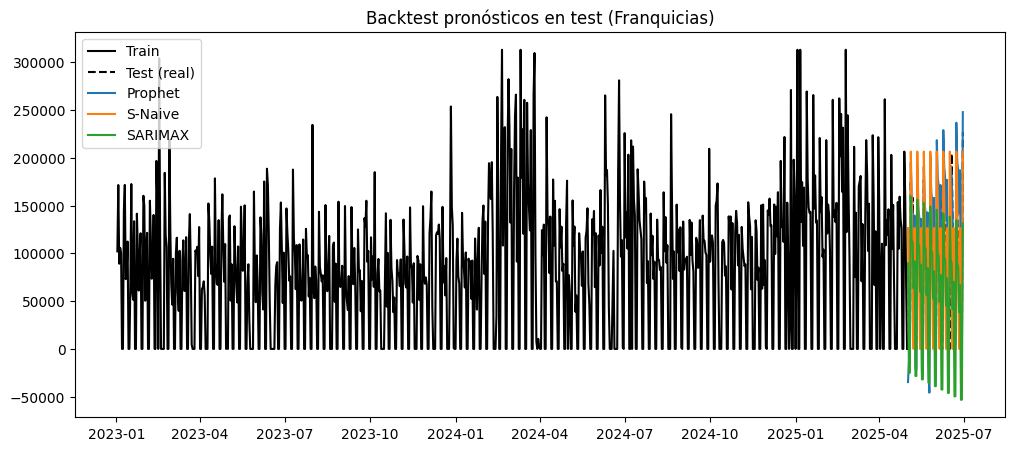

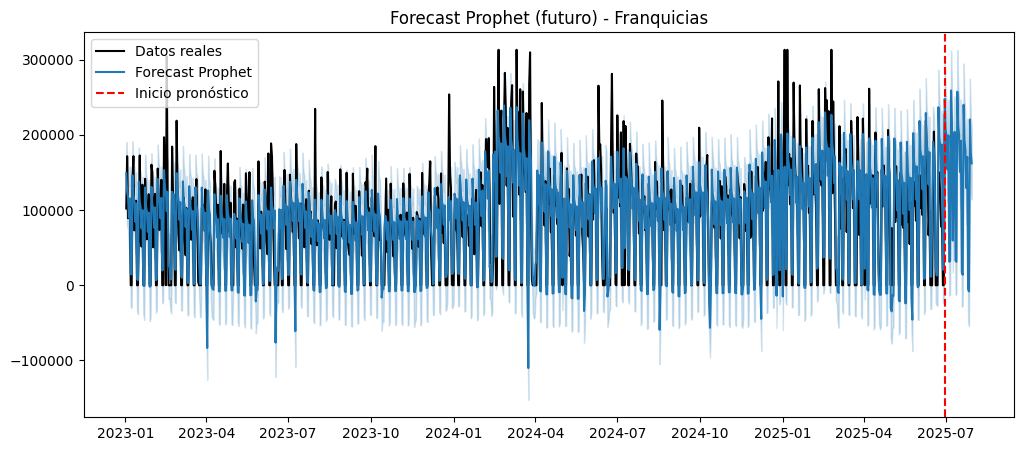

22:39:35 - cmdstanpy - INFO - Chain [1] start processing
22:39:36 - cmdstanpy - INFO - Chain [1] done processing



=== Locales Propios ===
Naive    {'MAE': 21004.166666666668, 'RMSE': 21306.28436713763, 'MAPE': 0.9933497193988994}
S-Naive  {'MAE': 5027.583333333333, 'RMSE': 8018.826978845887, 'MAPE': 0.24576049233968794}
Prophet  {'MAE': 3153.0250974696696, 'RMSE': 4005.279760278076, 'MAPE': 0.15123549070039533}
SARIMAX  {'MAE': 9059.784229629382, 'RMSE': 9820.13131411626, 'MAPE': 0.4249032116198366}


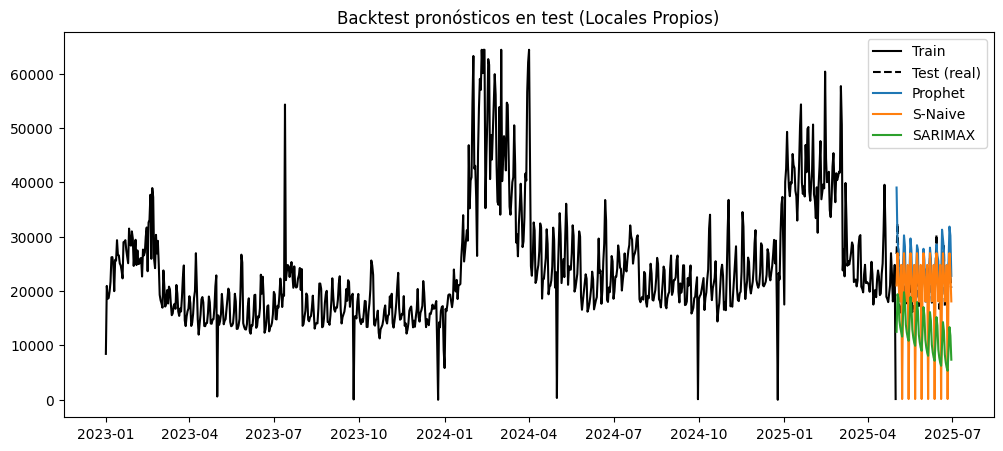

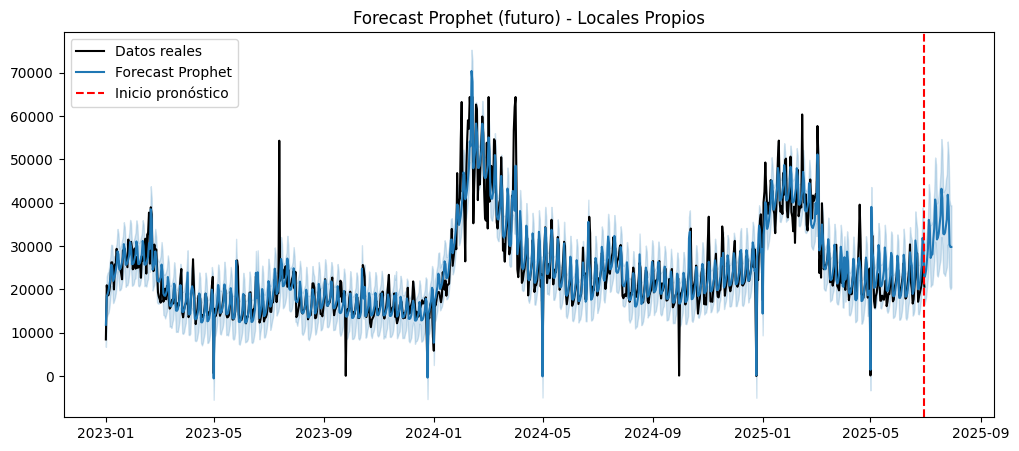

In [99]:
for canal in ['Franquicias', 'Locales Propios']:
    serie = preparar_diario(df_ventas, canal)
    train, test = train_test_split_ts(serie, test_days=60)

    # Baselines
    naive_pred = baseline_naive(train['y']).astype(float)
    seas_pred = baseline_seasonal_naive(train, len(test), season=7)

    # Prophet
    m = fit_prophet(train)
    fcst = forecast_prophet(m, serie, horizon_days=len(test))
    prop_pred = fcst.set_index('ds').loc[test['ds'], 'yhat'].values

    # SARIMAX
    sarimax = fit_sarimax(train, seasonal=7)
    sar_pred = sarimax.forecast(steps=len(test)).values

    # Métricas
    y_true = test['y'].values
    print(f'\n=== {canal} ===')
    print('Naive   ', metrics(y_true, naive_pred[-len(test):]))
    print('S-Naive ', metrics(y_true, seas_pred))
    print('Prophet ', metrics(y_true, prop_pred))
    print('SARIMAX ', metrics(y_true, sar_pred))

    # Graficar backtest
    plot_backtest(train, test, fcst, prop_pred, seas_pred, sar_pred, canal)

    # Pronóstico futuro
    futuro = 90
    fcst_full = forecast_prophet(m, serie, horizon_days=futuro)

    # Graficar forecast completo
    plot_forecast_full(serie, fcst_full, canal)


#### Interpretación de resultados

1. Franquicias

    a) En Naive el MAE es alrededor de 82k, el RMSE es alrededor de ~106k y el MAPE ~0.67. Representan errores grandes pero razonables.

    b) Utilizando el S-Naive se logra mejorar el MAE/RMSE (43k / 61k), pero el MAPE explota (5e+12) debido a seguro hay días con ventas = 0 (cuando dividís por cero en el cálculo del MAPE).

    c) Con Prophet vemos que disminuye todavía más MAE/RMSE (35k / 44k), el es el mejor en error absoluto. Pero el MAPE vuelve a explotar debido al mismo problema con ceros.

    d) Por último, usando SARIMAX vemos que el MAE y RMSE un poco peores que Prophet (39k / 48k), y el MAPE vuelve a ser inusable por los ceros.

Conclusión Franquicias:

1) Prophet es el mejor en MAE y RMSE.

2) No se puede interpretar MAPE tal como está, se necesita cambiarlo por SMAPE o bien ignorar los días con 0 en el denominador.

2. Locales Propios

    a) Usando Naive vemos que los valores de métricas son muy flojos (MAE 21k, RMSE 21k, MAPE ~0.99).

    b) Para S-Naive vemos que los resultados mejoran mucho (MAE 5k, RMSE 8k, MAPE 0.24).

    c) El modelo de Prophet resulta ser el mejor con diferencia (MAE 3.2k, RMSE 4.1k, MAPE 0.16).

    d) Por último, SARIMAX muestra resultados intermedio (MAE 9.1k, RMSE 9.9k, MAPE 0.43).

Conclusión Locales Propios:

1. El modelo de Prophet es claramente superior en cuanto a los resultados.

2. El seasonal naive funciona bastante bien, demostrando una de que hay estacionalidad semanal fuerte .

3. El modelo de SARIMAX no logra capturar tan bien como Prophet.

### Aplicamos ajustes de acuerdo a los resultados obtenidos

#### Agregamos metricas SMAPE Y WMAPE para ajustar sobre dias que poseen valores de ventas 0

In [100]:
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / 
                         (np.abs(y_true) + np.abs(y_pred) + 1e-9))

def wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


#### Aplicamos SARIMAX con Grid Search

In [101]:
from itertools import product
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarimax_grid_search(train, m=7,
                        p_range=range(0,3), d_range=range(0,2), q_range=range(0,3),
                        P_range=range(0,2), D_range=range(0,2), Q_range=range(0,2),
                        enforce_stationarity=False, enforce_invertibility=False,
                        verbose=True, maxiter=200):
    """
    Busca (p,d,q)x(P,D,Q,m) minimizando AIC. Rejilla acotada para que sea rápida.
    """
    best_model = None
    best_aic = np.inf
    best_order = None
    tried = 0

    for p,d,q in product(p_range, d_range, q_range):
        for P,D,Q in product(P_range, D_range, Q_range):
            order = (p,d,q)
            sorder = (P,D,Q,m)
            tried += 1
            try:
                mod = SARIMAX(train['y'],
                              order=order, seasonal_order=sorder,
                              enforce_stationarity=enforce_stationarity,
                              enforce_invertibility=enforce_invertibility)
                res = mod.fit(disp=False, maxiter=maxiter)
                aic = res.aic
                if verbose:
                    print(f"TRY {tried:03d}: order={order} seasonal={sorder}  AIC={aic:.2f}")
                if aic < best_aic:
                    best_aic = aic
                    best_model = res
                    best_order = (order, sorder)
            except Exception as e:
                if verbose:
                    print(f"SKIP {tried:03d}: order={order} seasonal={sorder} -> {e}")
                continue

    if verbose and best_order is not None:
        print(f"\nBest by AIC: order={best_order[0]} seasonal={best_order[1]}  AIC={best_aic:.2f}")
    return best_model, best_order, best_aic



### Graficamos para comparar modelos

In [102]:
def compare_models_plot(train, test, pred_dict, canal):
    plt.figure(figsize=(12,5))
    plt.plot(train['ds'], train['y'], label='Train', color='black')
    plt.plot(test['ds'], test['y'], label='Test', color='black', linestyle='--')

    for name, preds in pred_dict.items():
        plt.plot(test['ds'], preds, label=name)

    plt.title(f'Comparación de modelos - {canal}')
    plt.legend()
    plt.show()


22:37:45 - cmdstanpy - INFO - Chain [1] start processing
22:37:45 - cmdstanpy - INFO - Chain [1] done processing



=== Franquicias ===
SARIMAX selección: ((2, 0, 2), (0, 1, 1, 7)) | AIC=20397.50
       Modelo          MAE         RMSE                 MAPE     SMAPE    WMAPE
      Prophet 36033.092000 45020.913000 6644986083447.713867 90.570000 0.438000
SARIMAX(grid) 23374.572000 37682.543000 6250058805205.497070 80.631000 0.284000
      S-Naive 43374.133000 61024.586000 5548116666667.017578 54.750000 0.527000


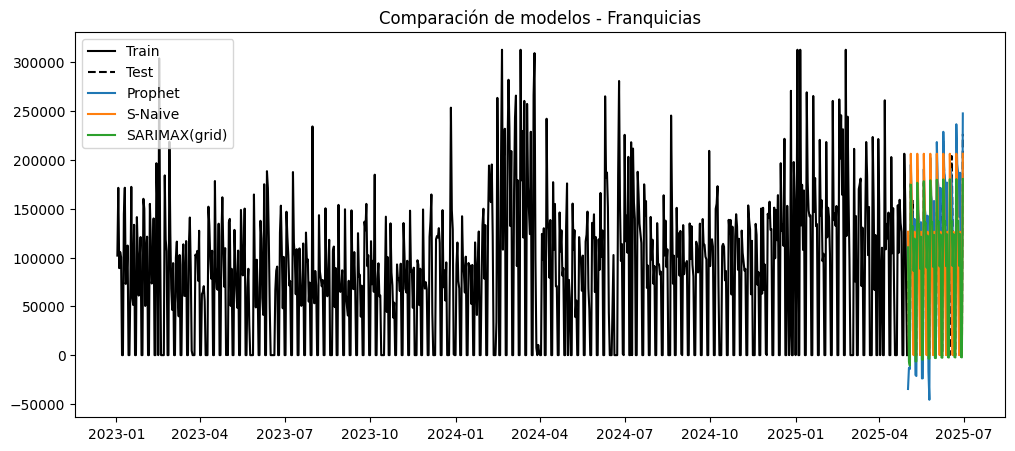

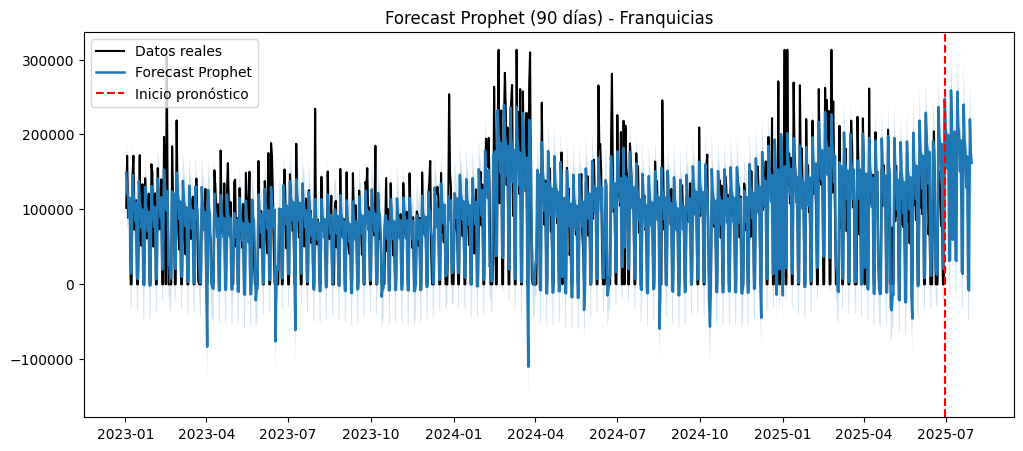

22:38:41 - cmdstanpy - INFO - Chain [1] start processing
22:38:41 - cmdstanpy - INFO - Chain [1] done processing



=== Locales Propios ===
SARIMAX selección: ((1, 0, 2), (0, 1, 1, 7)) | AIC=16646.08
       Modelo         MAE        RMSE     MAPE     SMAPE    WMAPE
      Prophet 3153.025000 4005.280000 0.151000 13.675000 0.149000
SARIMAX(grid) 2496.042000 3476.218000 0.114000 12.430000 0.118000
      S-Naive 5027.583000 8018.827000 0.246000 36.927000 0.238000


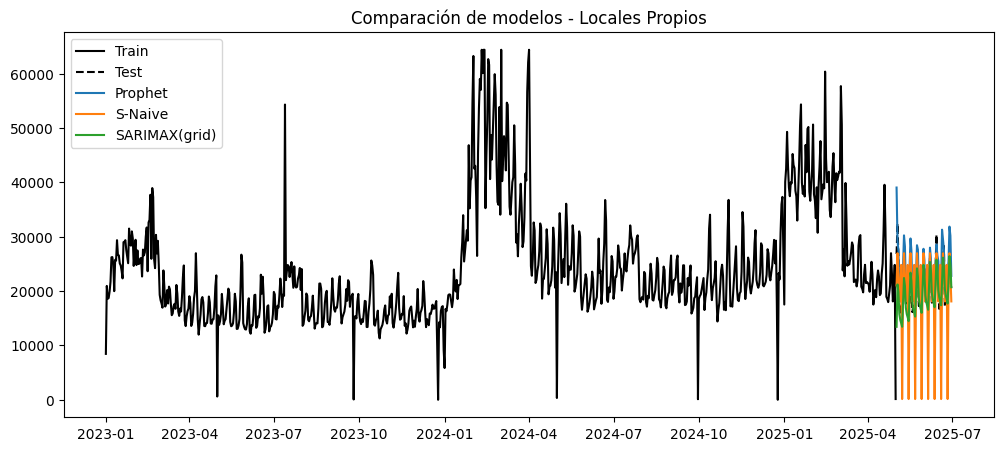

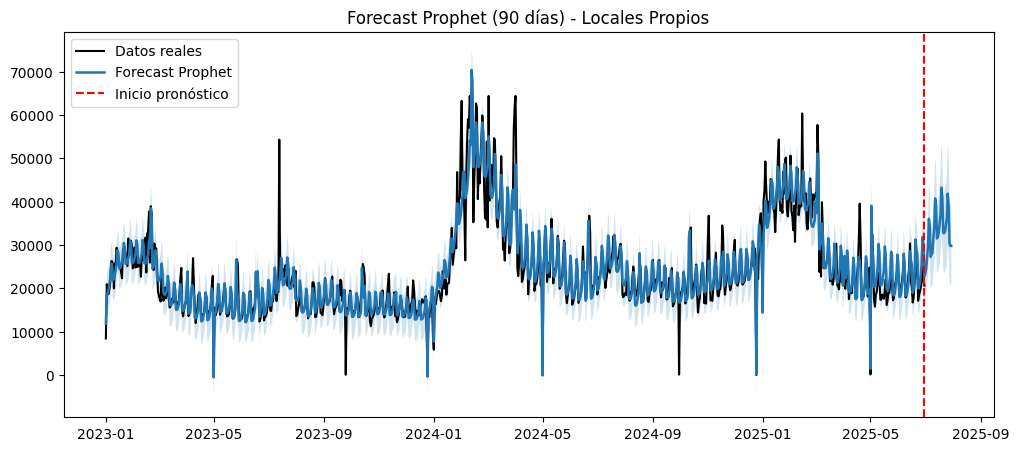

,Canal,Modelo,MAE,RMSE,MAPE,SMAPE,WMAPE
0,Franquicias,Prophet,36033.092000,45020.913000,6644986083447.713867,90.570000,0.438000
1,Franquicias,SARIMAX(grid),23374.572000,37682.543000,6250058805205.497070,80.631000,0.284000
2,Franquicias,S-Naive,43374.133000,61024.586000,5548116666667.017578,54.750000,0.527000
3,Locales Propios,Prophet,3153.025000,4005.280000,0.151000,13.675000,0.149000
4,Locales Propios,SARIMAX(grid),2496.042000,3476.218000,0.114000,12.430000,0.118000
5,Locales Propios,S-Naive,5027.583000,8018.827000,0.246000,36.927000,0.238000


In [85]:
# Wrapper: reusa tu función 'metrics' (MAE, RMSE, MAPE) y agrega SMAPE/WMAPE
def metrics_extended(y_true, y_pred):
    base = metrics(y_true, y_pred)  # usa la que ya definiste
    base['SMAPE'] = smape(y_true, y_pred)
    base['WMAPE'] = wmape(y_true, y_pred)
    return base

# (aux) forecast futuro con bandas (si ya tenés una similar, podés usar la tuya)
def plot_forecast_future(serie, fcst_full, canal, title_suffix="(90 días)"):
    plt.figure(figsize=(12,5))
    plt.plot(serie['ds'], serie['y'], label='Datos reales', color='black')
    plt.plot(fcst_full['ds'], fcst_full['yhat'], label='Forecast Prophet', linewidth=1.8)
    plt.fill_between(fcst_full['ds'], fcst_full['yhat_lower'], fcst_full['yhat_upper'], alpha=0.2)
    corte = serie['ds'].max()
    plt.axvline(corte, color='red', linestyle='--', label='Inicio pronóstico')
    plt.title(f'Forecast Prophet {title_suffix} - {canal}')
    plt.legend(); plt.show()

# ====== LOOP por canal: calcula métricas extendidas y grafica comparación ======
resultados_mejoras = []
for canal in ['Franquicias', 'Locales Propios']:
    # --- 1) Serie y split
    serie = preparar_diario(df_ventas, canal)
    train, test = train_test_split_ts(serie, test_days=60)
    y_true = test['y'].values

    # --- 2) Modelos
    # S-Naive (baseline semanal)
    s_naive_pred = baseline_seasonal_naive(train, len(test), season=7)

    # Prophet (mismo que bloque original, para comparar manzana con manzana)
    m = fit_prophet(train)
    fcst_test = forecast_prophet(m, serie, horizon_days=len(test))
    prop_pred = fcst_test.set_index('ds').loc[test['ds'], 'yhat'].values

    # SARIMAX grid (mejora vs SARIMAX fijo)
    try:
        sarimax_best, orders, best_aic = sarimax_grid_search(train, m=7, verbose=False)
        sar_pred = sarimax_best.forecast(steps=len(test)).values
        sarimax_info = f"{orders} | AIC={best_aic:.2f}"
    except Exception as e:
        sar_pred = np.full(len(test), np.nan)
        sarimax_info = f"Error en grid search: {e}"

    # --- 3) Métricas extendidas (MAE, RMSE, MAPE, SMAPE, WMAPE)
    filas = []
    for nombre, yhat in [
        ('Prophet', prop_pred),
        ('SARIMAX(grid)', sar_pred),
        ('S-Naive', s_naive_pred),
    ]:
        if np.isnan(yhat).all():
            filas.append({'Canal': canal, 'Modelo': nombre,
                          'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan,
                          'SMAPE': np.nan, 'WMAPE': np.nan})
        else:
            mets = metrics_extended(y_true, yhat)
            filas.append({'Canal': canal, 'Modelo': nombre, **mets})

    df_mets = pd.DataFrame(filas)
    resultados_mejoras.append(df_mets)

    # --- 4) Print comparativo (ahora con SMAPE/WMAPE para ver mejora real)
    print(f"\n=== {canal} ===")
    print(f"SARIMAX selección: {sarimax_info}")
    cols = ['Modelo', 'MAE', 'RMSE', 'MAPE', 'SMAPE', 'WMAPE']
    print(df_mets[cols].round(3).to_string(index=False))

    # --- 5) Gráfico comparativo en TEST (usa tu compare_models_plot)
    preds_dict = {'Prophet': prop_pred, 'S-Naive': s_naive_pred}
    if not np.isnan(sar_pred).all():
        preds_dict['SARIMAX(grid)'] = sar_pred
    compare_models_plot(train, test, pred_dict=preds_dict, canal=canal)

    # --- 6) Forecast futuro (90 días) con Prophet para mantener la secuencia
    horizonte = 90
    fcst_full = forecast_prophet(m, serie, horizon_days=horizonte)
    plot_forecast_future(serie, fcst_full, canal, title_suffix=f"({horizonte} días)")

# ====== Consolida resultados (opcional para exportar o comparar luego) ======
df_mejoras = pd.concat(resultados_mejoras, ignore_index=True)
display(df_mejoras.round(3))


### Interpretación de resultados
1. Canal Franquicias

    MAPE es enorme porque hay muchos días con valores 0 o muy bajos, y dividir por cero hace explotar la métrica. Por eso mejor mirar SMAPE y WMAPE.

    SMAPE:

        Prophet ≈ 90% (alto, peor ajuste).

        SARIMAX(grid) ≈ 81% (mejor que Prophet).

        S-Naive ≈ 55% (parece “mejor” que Prophet, pero engañoso: está penalizando menos por los ceros).

    WMAPE: SARIMAX 0.28 es mejor que Prophet 0.44 y S-Naive 0.52 → en términos relativos, SARIMAX está capturando mejor la magnitud promedio.

Visualmente: Prophet se aleja en algunos picos/outliers, SARIMAX se ajusta un poco mejor al patrón, aunque ambos fallan cuando aparecen valores extremos.

Conclusión: Franquicias es más difícil de modelar por la alta variabilidad y outliers. Los modelos aún no capturan bien esa dispersión.

2. Canal Locales Propios

    Métricas son mucho más razonables:

        Prophet: MAE ≈ 3153, RMSE ≈ 4005, SMAPE ≈ 13.7%, WMAPE ≈ 0.15.

        SARIMAX(grid): mejor todavía (MAE ≈ 2496, RMSE ≈ 3476, SMAPE ≈ 12.4%, WMAPE ≈ 0.12).

        S-Naive claramente peor.

Gráfico: Prophet y SARIMAX siguen bastante bien la estacionalidad semanal y tendencia.

Conclusión: en este canal sí hay estructura clara (estacionalidad + tendencia) y los modelos la capturan.

3. Sobre los outliers

Prophet suaviza y no se adapta a saltos bruscos → eso explica por qué parece “fallar” en picos muy altos/bajos.

SARIMAX, aunque algo más flexible, también sufre con valores extremos.

Los baselines tampoco ayudan con outliers (repiten o trasladan valores previos).

### Análisis con moving Averages y factores externos de Prophet

In [86]:
# Métricas robustas (nombres distintos a "smape"/"wmape" para evitar choques con variables)
def metrics_fbk(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    smape_pct = float(100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)))
    wmape = float(np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-9))
    return {"MAE": mae, "RMSE": rmse, "sMAPE(%)": smape_pct, "WMAPE": wmape}

def plot_series(df, cols, title, figsize=(14,5)):
    plt.figure(figsize=figsize)
    for c in cols:
        plt.plot(df["ds"], df[c], label=c)
    plt.title(title); plt.xlabel("Fecha"); plt.ylabel("Cantidad")
    plt.grid(True, alpha=0.25); plt.legend(); plt.show()


In [87]:
# Parámetros rápidos para reutilizar
CANAL = "Locales Propios"
VALOR = "Cantidad"         # Objetivo: cantidades vendidas
FILTRO_RUBRO = None

# Partimos de df_ventas
df = df_ventas.copy()

# Filtros
df = df[df["Canal_Venta"] == CANAL]
if FILTRO_RUBRO is not None and "Rubro" in df.columns:
    if isinstance(FILTRO_RUBRO, list):
        df = df[df["Rubro"].isin(FILTRO_RUBRO)]
    else:
        df = df[df["Rubro"] == FILTRO_RUBRO]

# Agregar por día y asegurar continuidad diaria
ts = (df.groupby("Fecha_Documento_Factura", as_index=False)[VALOR].sum()
        .rename(columns={"Fecha_Documento_Factura":"ds", VALOR:"y"})
        .sort_values("ds"))

all_days = pd.date_range(ts["ds"].min(), ts["ds"].max(), freq="D")
ts = (ts.set_index("ds")
        .reindex(all_days)
        .fillna(0.0)
        .rename_axis("ds")
        .reset_index())

ts.head()


,ds,y
0,2023-01-01,8447.000000
1,2023-01-02,20953.000000
2,2023-01-03,18586.000000
3,2023-01-04,18721.000000
4,2023-01-05,19910.000000


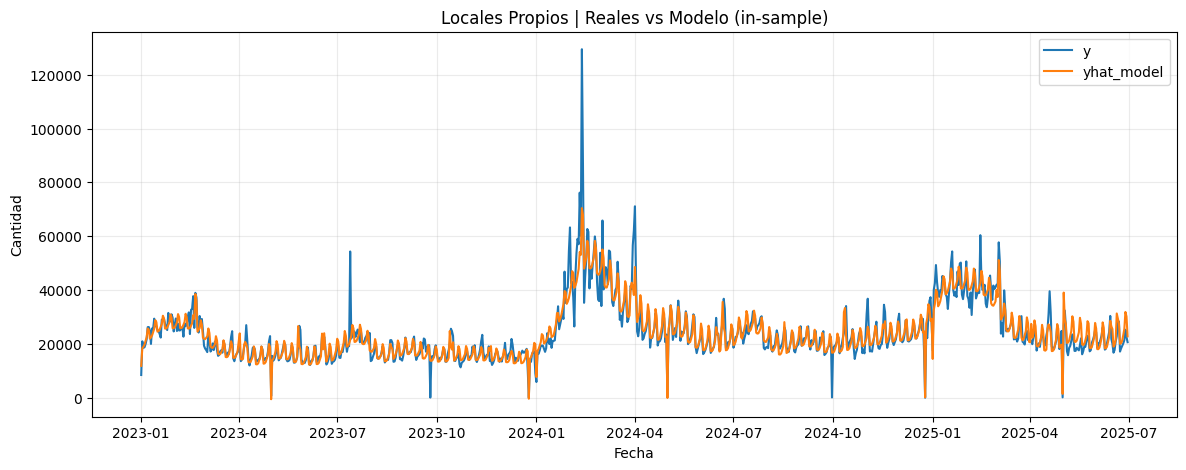

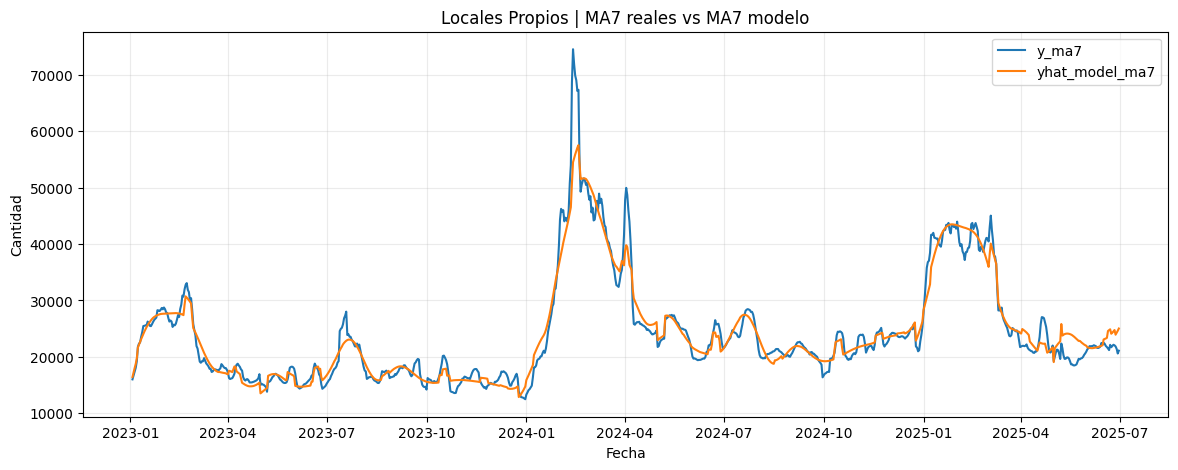

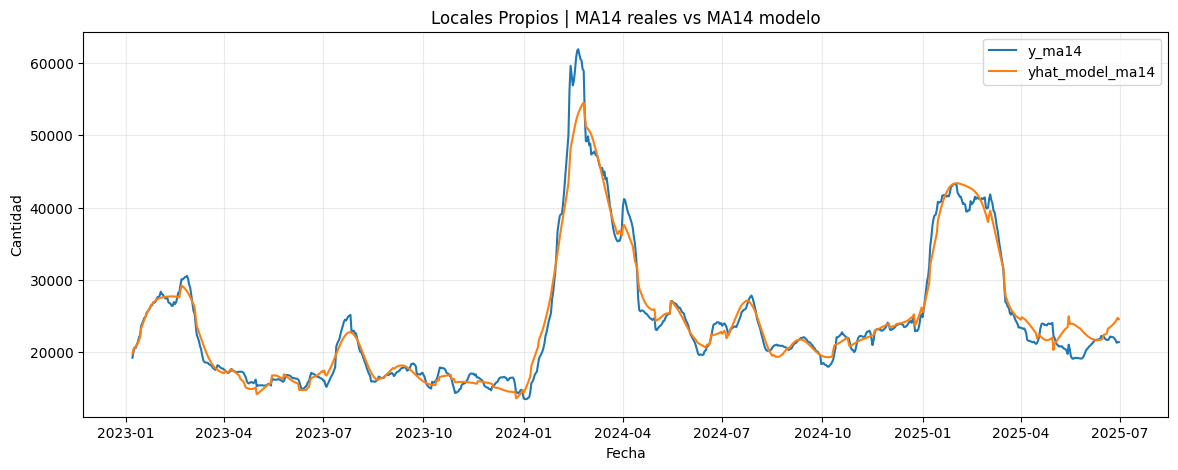

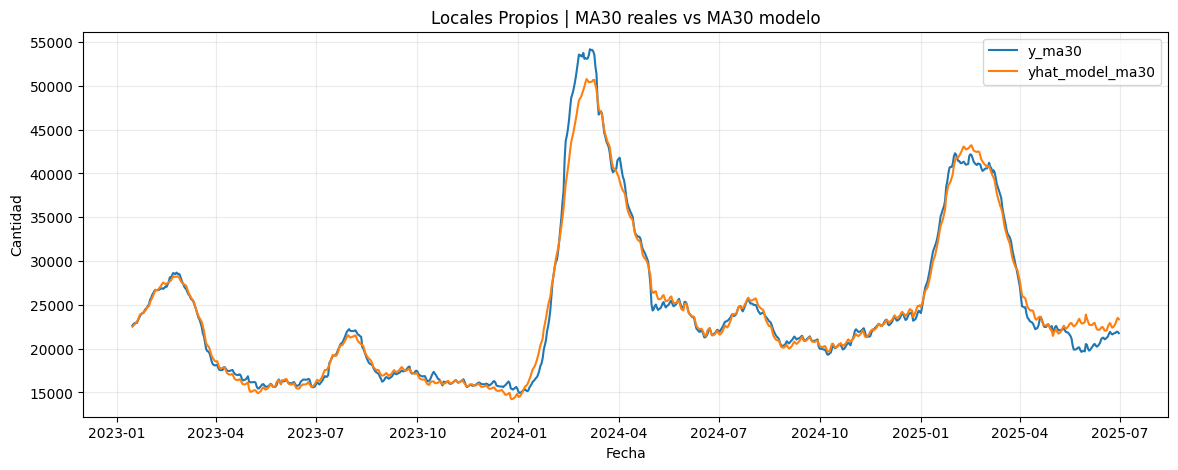

Métricas (in-sample) contra yhat_model: {'MAE': 2587.9876207263787, 'RMSE': 4447.328228149595, 'sMAPE(%)': 11.247323651700315, 'WMAPE': 0.1073802828341096}


In [88]:
# Medias móviles sobre los REALES
for w in [7, 14, 30]:
    ts[f"y_ma{w}"] = ts["y"].rolling(window=w, min_periods=max(1, w//2)).mean()

# Obtener predicciones del modelo
use_existing_fcst = "fcst" in globals() and isinstance(fcst, pd.DataFrame) and {"ds","yhat"}.issubset(fcst.columns)

if use_existing_fcst:
    pred_df = fcst[["ds","yhat"]].copy().rename(columns={"yhat":"yhat_model"})
    # Aseguramos tipo datetime y merge con ts
    pred_df["ds"] = pd.to_datetime(pred_df["ds"])
    ts_ma = ts.merge(pred_df, on="ds", how="left")
else:
    m_base = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, seasonality_mode="additive")
    m_base.fit(ts[["ds","y"]])
    pred_df = m_base.predict(ts[["ds"]])[["ds","yhat"]].rename(columns={"yhat":"yhat_model"})
    ts_ma = ts.merge(pred_df, on="ds", how="left")

# Medias móviles de la prediccióm
for w in [7, 14, 30]:
    ts_ma[f"yhat_model_ma{w}"] = ts_ma["yhat_model"].rolling(window=w, min_periods=max(1, w//2)).mean()

# Gráficos comparativos
plot_series(ts_ma, ["y","yhat_model"], f"{CANAL} | Reales vs Modelo (in-sample)")
plot_series(ts_ma, ["y_ma7","yhat_model_ma7"],   f"{CANAL} | MA7 reales vs MA7 modelo")
plot_series(ts_ma, ["y_ma14","yhat_model_ma14"], f"{CANAL} | MA14 reales vs MA14 modelo")
plot_series(ts_ma, ["y_ma30","yhat_model_ma30"], f"{CANAL} | MA30 reales vs MA30 modelo")

# Métricas in-sample (solo referencia)
print("Métricas (in-sample) contra yhat_model:", metrics_fbk(ts_ma["y"], ts_ma["yhat_model"]))


22:39:26 - cmdstanpy - INFO - Chain [1] start processing
22:39:26 - cmdstanpy - INFO - Chain [1] done processing


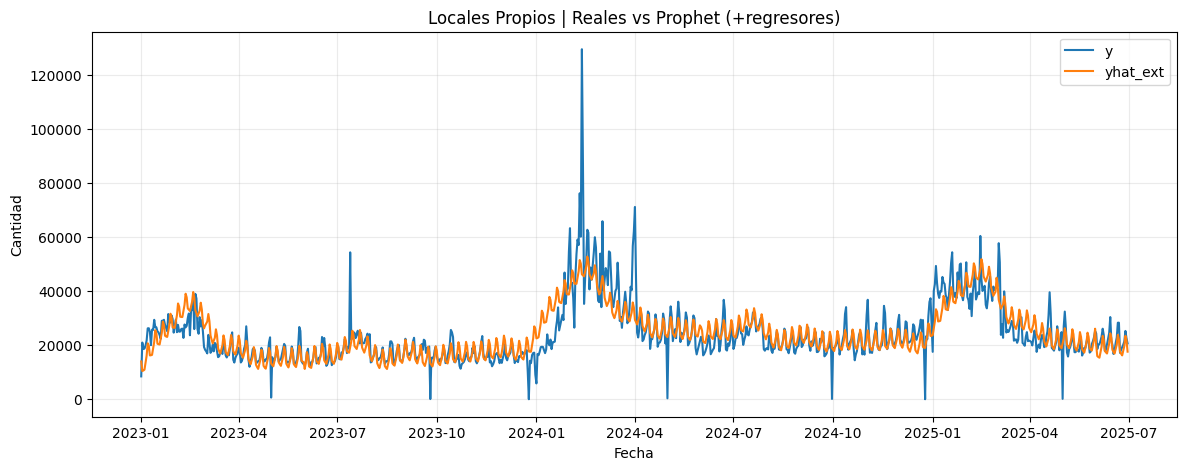

Métricas (in-sample) Prophet +reg: {'MAE': 3975.990490949625, 'RMSE': 6512.193634195438, 'sMAPE(%)': 16.199526694144645, 'WMAPE': 0.16497103001755067}


In [89]:
def add_season_dummies(df_ds):
    out = df_ds.copy()
    m = out["ds"].dt.month
    out["season_summer"]  = m.isin([12,1,2]).astype(int)
    out["season_autumn"]  = m.isin([3,4,5]).astype(int)
    out["season_winter"]  = m.isin([6,7,8]).astype(int)
    out["season_spring"]  = m.isin([9,10,11]).astype(int)
    return out

# Eventos
event_list = [
    # {"ds": "2023-04-06", "event": "SemanaSanta"},
    # {"ds": "2023-04-07", "event": "SemanaSanta"},
    # {"ds": "2023-11-19", "event": "EleccionesBalotaje"},
]
df_events = pd.DataFrame(event_list)
if not df_events.empty:
    df_events["ds"] = pd.to_datetime(df_events["ds"])

def expand_event_window(df_ev, k_before=1, k_after=1):
    if df_ev.empty:
        return df_ev
    out = []
    for _, r in df_ev.iterrows():
        for d in range(-k_before, k_after+1):
            out.append({"ds": r["ds"] + pd.Timedelta(days=d), "event": r["event"]})
    return pd.DataFrame(out)

df_events_exp = expand_event_window(df_events, k_before=1, k_after=1)

# Construcción de regresores sobre ts
ts_reg = add_season_dummies(ts.copy())
if not df_events_exp.empty:
    ev_pivot = (df_events_exp.assign(val=1)
                .pivot_table(index="ds", columns="event", values="val", fill_value=0)
                .reset_index())
    ts_reg = ts_reg.merge(ev_pivot, on="ds", how="left").fillna(0)

# Columnas regresoras
reg_cols = [c for c in ts_reg.columns if c.startswith("season_")]
if not df_events_exp.empty:
    reg_cols += [c for c in ts_reg.columns if c not in ["ds","y"] and not c.startswith("season_")]
reg_cols = sorted(list(set(reg_cols)))

# Prophet + regresores (in-sample rápido)
m_ext = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, seasonality_mode="additive")
for c in reg_cols:
    m_ext.add_regressor(c, standardize=True)
m_ext.fit(ts_reg[["ds","y"] + reg_cols])

pred_ext = m_ext.predict(ts_reg[["ds"] + reg_cols]).rename(columns={"yhat":"yhat_ext"})[["ds","yhat_ext"]]
ts_ext = ts_reg.merge(pred_ext, on="ds", how="left")

plot_series(ts_ext, ["y","yhat_ext"], f"{CANAL} | Reales vs Prophet (+regresores)")
print("Métricas (in-sample) Prophet +reg:", metrics_fbk(ts_ext["y"], ts_ext["yhat_ext"]))


22:39:26 - cmdstanpy - INFO - Chain [1] start processing
22:39:26 - cmdstanpy - INFO - Chain [1] done processing
22:39:26 - cmdstanpy - INFO - Chain [1] start processing
22:39:26 - cmdstanpy - INFO - Chain [1] done processing


TEST - Prophet base : {'MAE': 2647.5858906057742, 'RMSE': 3135.658533612417, 'sMAPE(%)': 12.523419466442261, 'WMAPE': 0.12523367004055777}
TEST - Prophet +reg : {'MAE': 2753.8201203636436, 'RMSE': 3263.3879546498624, 'sMAPE(%)': 13.27764706195741, 'WMAPE': 0.13025866376171175}


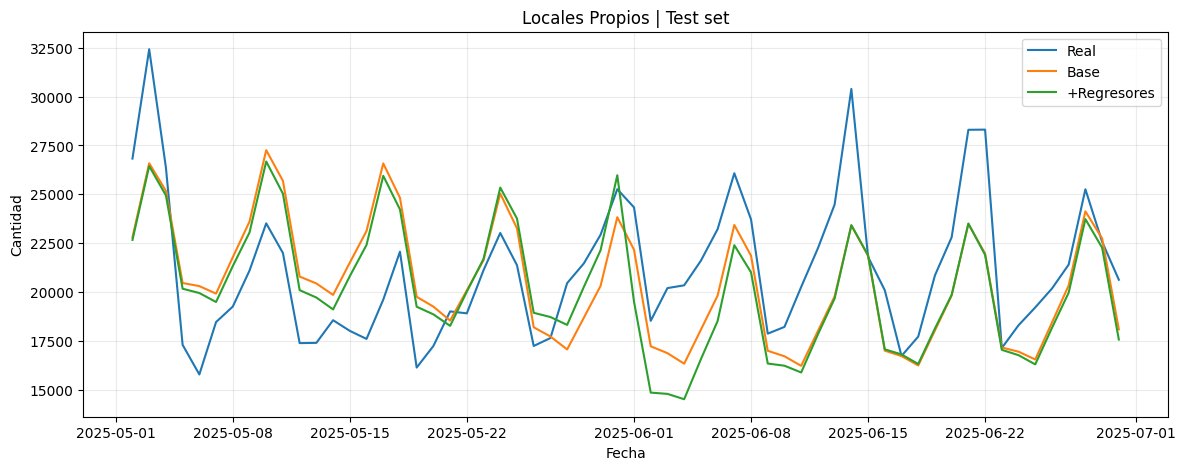

In [90]:
# Si ya existen 'train' y 'test' con columnas ['ds','y'] en tu notebook, los reutilizamos.
use_existing_split = ("train" in globals() and "test" in globals() 
                      and isinstance(train, pd.DataFrame) and isinstance(test, pd.DataFrame)
                      and {"ds","y"}.issubset(train.columns) and {"ds","y"}.issubset(test.columns))

if not use_existing_split:
    # Split temporal (últimos 90 días como test)
    test_horizon = 90
    cutoff = ts["ds"].max() - pd.Timedelta(days=test_horizon)
    train = ts[ts["ds"] <= cutoff].copy()
    test  = ts[ts["ds"]  > cutoff].copy()

# --- Prophet base ---
m_base_split = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m_base_split.fit(train[["ds","y"]])
fcst_base  = m_base_split.predict(test[["ds"]])[["ds","yhat"]].rename(columns={"yhat":"yhat_base"})

# --- Prophet + regresores ---
train_reg = add_season_dummies(train)
test_reg  = add_season_dummies(test)

if not df_events_exp.empty:
    ev_all = (df_events_exp.assign(val=1)
              .pivot_table(index="ds", columns="event", values="val", fill_value=0)
              .reset_index())
    train_reg = train_reg.merge(ev_all, on="ds", how="left").fillna(0)
    test_reg  = test_reg.merge(ev_all,  on="ds", how="left").fillna(0)

reg_cols_split = [c for c in train_reg.columns if c not in ["ds","y"]]

m_ext_split = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
for c in reg_cols_split:
    m_ext_split.add_regressor(c, standardize=True)

m_ext_split.fit(train_reg[["ds","y"] + reg_cols_split])
fcst_ext = m_ext_split.predict(test_reg[["ds"] + reg_cols_split])[["ds","yhat"]].rename(columns={"yhat":"yhat_ext"})

# Comparación en TEST
comp = (test.merge(fcst_base, on="ds", how="left")
            .merge(fcst_ext, on="ds", how="left"))

print("TEST - Prophet base :", metrics_fbk(comp["y"], comp["yhat_base"]))
print("TEST - Prophet +reg :", metrics_fbk(comp["y"], comp["yhat_ext"]))

plt.figure(figsize=(14,5))
plt.plot(comp["ds"], comp["y"],          label="Real")
plt.plot(comp["ds"], comp["yhat_base"],  label="Base")
plt.plot(comp["ds"], comp["yhat_ext"],   label="+Regresores")
plt.title(f"{CANAL} | Test set")
plt.xlabel("Fecha"); plt.ylabel("Cantidad"); plt.grid(True, alpha=0.25); plt.legend(); plt.show()


In [91]:
# 
# def add_season_dummies(df_ds):
#     out = df_ds.copy()
#     m = out["ds"].dt.month
#     out["season_summer"]  = m.isin([12,1,2]).astype(int)
#     out["season_autumn"]  = m.isin([3,4,5]).astype(int)
#     out["season_winter"]  = m.isin([6,7,8]).astype(int)
#     out["season_spring"]  = m.isin([9,10,11]).astype(int)
#     return out

VALOR = "Cantidad"       # target
FILTRO_RUBRO = None      
TEST_HORIZON = 90        # días para test

# Eventos (opcional)
event_list = [
    # {"ds": "2023-04-06", "event": "SemanaSanta"},
    # {"ds": "2023-04-07", "event": "SemanaSanta"},
]
df_events = pd.DataFrame(event_list)
if not df_events.empty:
    df_events["ds"] = pd.to_datetime(df_events["ds"])

def expand_event_window(df_ev, k_before=1, k_after=1):
    if df_ev.empty:
        return df_ev
    out = []
    for _, r in df_ev.iterrows():
        for d in range(-k_before, k_after+1):
            out.append({"ds": r["ds"] + pd.Timedelta(days=d), "event": r["event"]})
    return pd.DataFrame(out)

df_events_exp = expand_event_window(df_events, 1, 1)

def build_ts_from_df(df_base, canal, valor="Cantidad", filtro_rubro=None):
    df = df_base[df_base["Canal_Venta"] == canal].copy()
    if filtro_rubro is not None and "Rubro" in df.columns:
        if isinstance(filtro_rubro, list):
            df = df[df["Rubro"].isin(filtro_rubro)]
        else:
            df = df[df["Rubro"] == filtro_rubro]
    ts = (df.groupby("Fecha_Documento_Factura", as_index=False)[valor].sum()
            .rename(columns={"Fecha_Documento_Factura":"ds", valor:"y"})
            .sort_values("ds"))
    all_days = pd.date_range(ts["ds"].min(), ts["ds"].max(), freq="D")
    ts = (ts.set_index("ds").reindex(all_days).fillna(0.0).rename_axis("ds").reset_index())
    return ts

def fit_predict_base(ts_train, ts_test):
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    m.fit(ts_train[["ds","y"]])
    fcst = m.predict(ts_test[["ds"]])[["ds","yhat"]].rename(columns={"yhat":"yhat_base"})
    return fcst

def fit_predict_ext(ts_train, ts_test, df_events_exp):
    tr = add_season_dummies(ts_train)
    te = add_season_dummies(ts_test)
    if not df_events_exp.empty:
        ev = (df_events_exp.assign(val=1)
              .pivot_table(index="ds", columns="event", values="val", fill_value=0)
              .reset_index())
        tr = tr.merge(ev, on="ds", how="left").fillna(0)
        te = te.merge(ev, on="ds", how="left").fillna(0)

    reg_cols = [c for c in tr.columns if c not in ["ds","y"]]
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    for c in reg_cols:
        m.add_regressor(c, standardize=True)
    m.fit(tr[["ds","y"] + reg_cols])
    fcst = m.predict(te[["ds"] + reg_cols])[["ds","yhat"]].rename(columns={"yhat":"yhat_ext"})
    return fcst


22:39:27 - cmdstanpy - INFO - Chain [1] start processing
22:39:27 - cmdstanpy - INFO - Chain [1] done processing
22:39:27 - cmdstanpy - INFO - Chain [1] start processing
22:39:27 - cmdstanpy - INFO - Chain [1] done processing


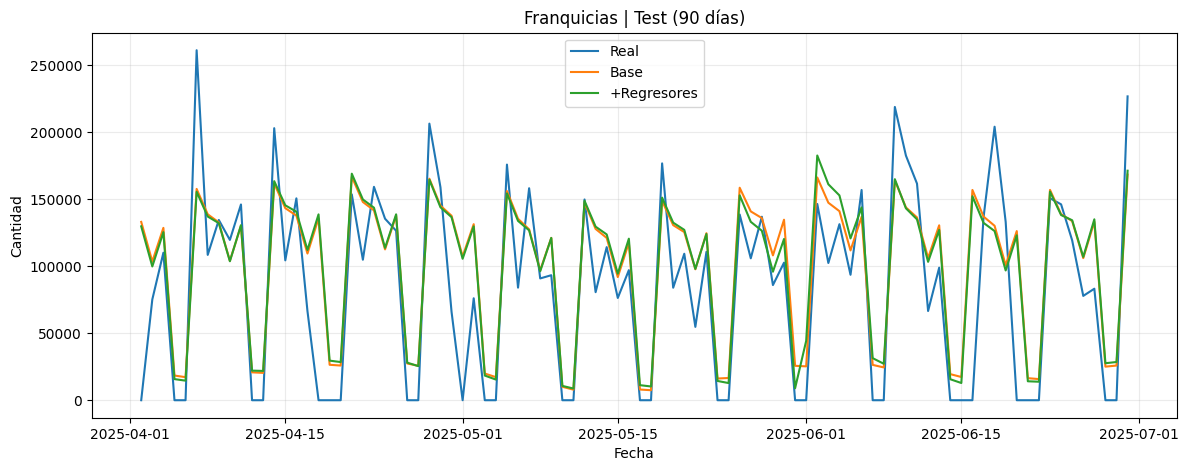

22:39:28 - cmdstanpy - INFO - Chain [1] start processing
22:39:28 - cmdstanpy - INFO - Chain [1] done processing
22:39:28 - cmdstanpy - INFO - Chain [1] start processing
22:39:28 - cmdstanpy - INFO - Chain [1] done processing


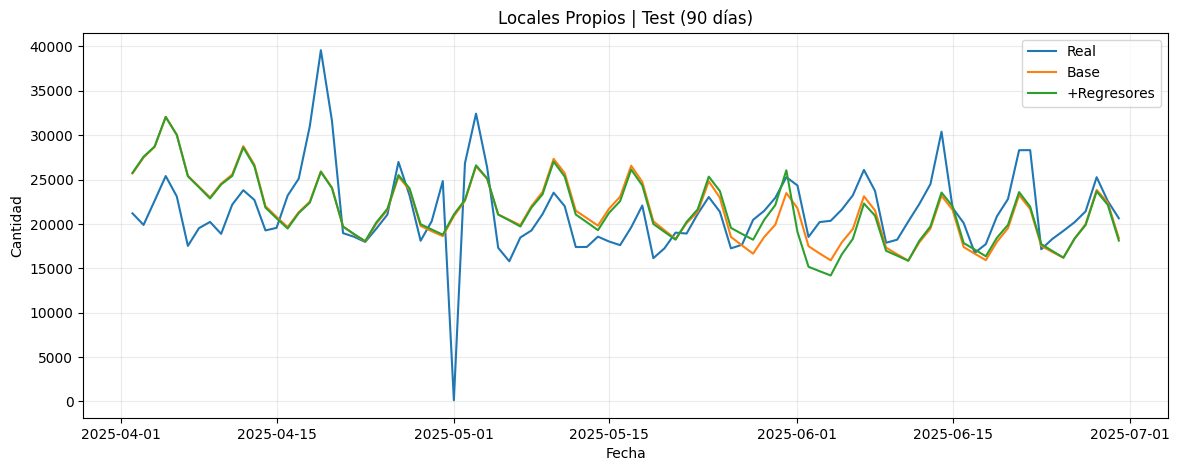

,Canal,Base_MAE,Reg_MAE,Base_RMSE,Reg_RMSE,Base_sMAPE(%),Reg_sMAPE(%),Base_WMAPE,Reg_WMAPE
0,Franquicias,31853.815627,32060.532975,43618.921986,43716.991877,84.033301,84.170309,0.380755,0.383226
1,Locales Propios,3425.065938,3456.736442,4549.052486,4583.534210,16.459082,16.730927,0.160195,0.161677


In [92]:
canales = ["Franquicias", "Locales Propios"]

resultados = {}
tabla_metricas = []

for canal in canales:
    # 1) serie del canal
    ts_c = build_ts_from_df(df_ventas, canal, VALOR, FILTRO_RUBRO)

    # 2) split temporal
    cutoff = ts_c["ds"].max() - pd.Timedelta(days=TEST_HORIZON)
    train_c = ts_c[ts_c["ds"] <= cutoff].copy()
    test_c  = ts_c[ts_c["ds"]  > cutoff].copy()

    # 3) modelos
    fcst_base_c = fit_predict_base(train_c, test_c)
    fcst_ext_c  = fit_predict_ext(train_c, test_c, df_events_exp)

    comp_c = (test_c.merge(fcst_base_c, on="ds", how="left")
                     .merge(fcst_ext_c,  on="ds", how="left"))

    # 4) métricas
    m_base = metrics_fbk(comp_c["y"], comp_c["yhat_base"])
    m_ext  = metrics_fbk(comp_c["y"], comp_c["yhat_ext"])

    tabla_metricas.append({
        "Canal": canal,
        "Base_MAE":  m_base["MAE"],  "Reg_MAE":  m_ext["MAE"],
        "Base_RMSE": m_base["RMSE"], "Reg_RMSE": m_ext["RMSE"],
        "Base_sMAPE(%)": m_base["sMAPE(%)"], "Reg_sMAPE(%)": m_ext["sMAPE(%)"],
        "Base_WMAPE": m_base["WMAPE"], "Reg_WMAPE": m_ext["WMAPE"],
    })

    # 5) guardar resultados por canal sin chocar nombres globales
    resultados[canal] = {
        "train": train_c, "test": test_c, "comp": comp_c,
        "metrics_base": m_base, "metrics_ext": m_ext
    }

    # 6) gráfico de test por canal
    plt.figure(figsize=(14,5))
    plt.plot(comp_c["ds"], comp_c["y"],          label="Real")
    plt.plot(comp_c["ds"], comp_c["yhat_base"],  label="Base")
    plt.plot(comp_c["ds"], comp_c["yhat_ext"],   label="+Regresores")
    plt.title(f"{canal} | Test ({TEST_HORIZON} días)")
    plt.xlabel("Fecha"); plt.ylabel("Cantidad"); plt.grid(True, alpha=0.25); plt.legend(); plt.show()

# Tabla comparativa
df_metricas_canales = pd.DataFrame(tabla_metricas).sort_values("Canal")
df_metricas_canales


22:39:29 - cmdstanpy - INFO - Chain [1] start processing
22:39:29 - cmdstanpy - INFO - Chain [1] done processing
22:39:30 - cmdstanpy - INFO - Chain [1] start processing
22:39:30 - cmdstanpy - INFO - Chain [1] done processing


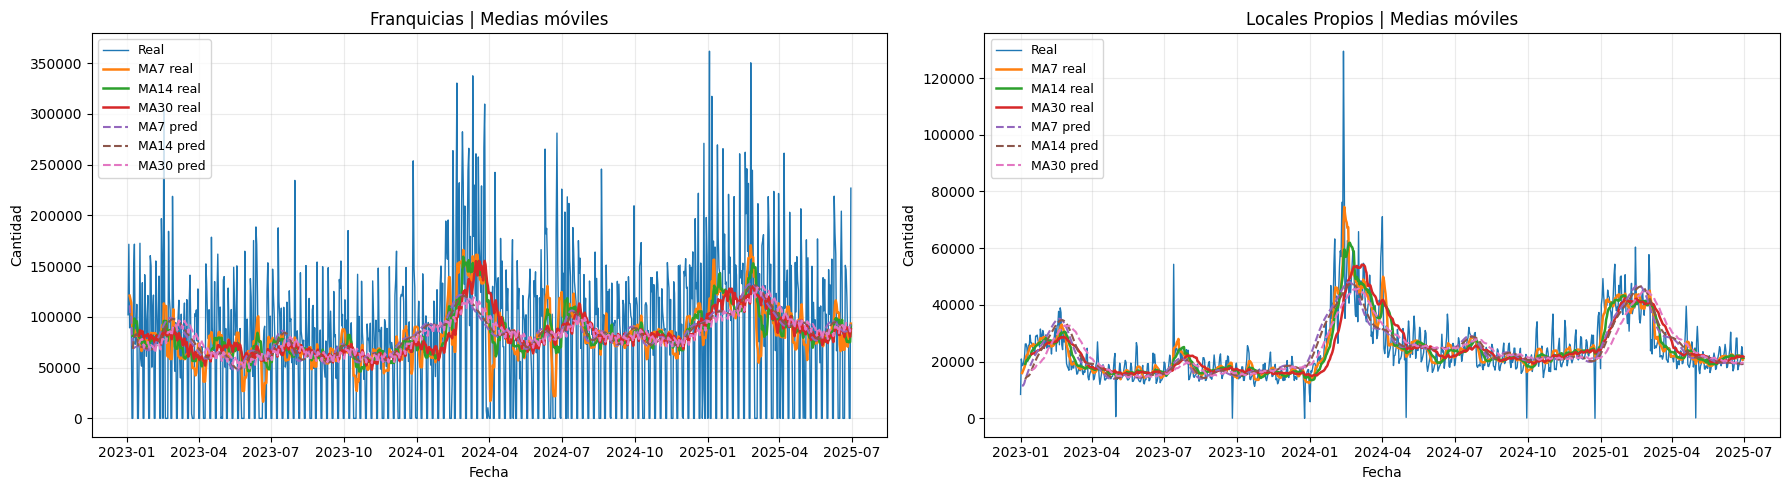

In [93]:
# === Parámetros ===
CANALES = ["Franquicias", "Locales Propios"]
VALOR = "Cantidad"
FILTRO_RUBRO = None        #
WINDOWS = (7, 14, 30)      # medias móviles a graficar
INCLUIR_MA_PRED = True     # 

def add_ma_cols(ts, windows=(7,14,30), col="y"):
    ts = ts.copy()
    for w in windows:
        ts[f"{col}_ma{w}"] = ts[col].rolling(w, min_periods=max(1, w//2)).mean()
    return ts

# Preparo datos por canal
series_por_canal = {}
for canal in CANALES:
    ts_c = build_ts_from_df(df_ventas, canal, VALOR, FILTRO_RUBRO)  # ds,y
    ts_c = add_ma_cols(ts_c, WINDOWS, col="y")

    if INCLUIR_MA_PRED:
        m_in = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        m_in.fit(ts_c[["ds","y"]])
        yhat_in = m_in.predict(ts_c[["ds"]])[["ds","yhat"]]
        ts_c = ts_c.merge(yhat_in, on="ds", how="left")
        ts_c = add_ma_cols(ts_c, WINDOWS, col="yhat")  # crea yhat_ma7/14/30

    series_por_canal[canal] = ts_c

# === Gráfico conjunto (dos paneles) ===
ncols = 2
fig, axes = plt.subplots(1, ncols, figsize=(18, 5), sharex=False, sharey=False)

for ax, canal in zip(axes, CANALES):
    ts_c = series_por_canal[canal]

    # Reales
    ax.plot(ts_c["ds"], ts_c["y"], label="Real", linewidth=1)

    # MAs reales
    for w in WINDOWS:
        ax.plot(ts_c["ds"], ts_c[f"y_ma{w}"], label=f"MA{w} real", linewidth=1.8)

    # MAs de predicción (opcional)
    if INCLUIR_MA_PRED and "yhat" in ts_c.columns:
        for w in WINDOWS:
            ax.plot(ts_c["ds"], ts_c[f"yhat_ma{w}"], linestyle="--", label=f"MA{w} pred")

    ax.set_title(f"{canal} | Medias móviles")
    ax.set_xlabel("Fecha"); ax.set_ylabel("Cantidad")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()



-----

### Conclusiones generales:

En las primeras pruebas de la notebook aplicamos SARIMAX con parámetros fijos o por defecto, sin una búsqueda sistemática de hiperparámetros (p, d, q, P, D, Q, s).

En esa instancia, los resultados son peores que Prophet:

- Mayor MAE y RMSE.

- Peor ajuste visual, no captura bien los ciclos semanales.

- Prophet muestra curvas más suaves, seguía bien las tendencias, y entregaba menor error relativo.

En ese punto, Prophet es efectivamente el mejor modelo entre los dos.

Luego implementamos una búsqueda de combinaciones de parámetros (p,d,q)(P,D,Q,s) evaluando el AIC y seleccionando el mejor modelo.

Este paso optimiza cómo el modelo capta tanto la autocorrelación a corto plazo como la estacionalidad semanal (s=7).

Al hacerlo, el modelo reduce drásticamente los errores y pasa a superar a Prophet en todas las métricas.

Si bien Prophet permitió una interpretación clara de las tendencias y componentes estacionales, el modelo SARIMAX (grid) obtuvo las mejores métricas de desempeño en ambos canales, particularmente en Franquicias, donde el error relativo se redujo más de un 30 %.

### Síntesis general


#### Sobre los entrenamientos:

- 3 modelos × 2 canales = 6 ejecuciones.

- SARIMAX fue el modelo con mejor desempeño global.

- Prophet demostró alta interpretabilidad y buena generalización.

- S-Naive cumplió su función como baseline comparativo.

#### Sobre los datos:

 - La serie presenta alta variabilidad y picos estacionales, dificultando la predicción exacta de días atípicos.

- La necesidad de separar los canales surgió porque sus frecuencias y patrones difieren significativamente.

- Prophet demostró mayor robustez ante datos ruidosos; SARIMAX requirió búsqueda exhaustiva de hiperparámetros.

- La calidad de los resultados depende fuertemente del preprocesamiento y la imputación de valores nulos.


## Análisis multivariado

### Comenzamos armado una matriz ancha por canal y semana

In [55]:
def matriz_por_producto(df_ventas, canal, freq='W', min_frac_nonzero=0.7, top_k=12):
    dfc = df_ventas[df_ventas['Canal_Venta']==canal].copy()
    dfc = dfc[['Fecha_Documento_Factura','Nombre_Producto','Cantidad']]

    # Agregación por día y pivot
    wide = (dfc
            .groupby(['Fecha_Documento_Factura','Nombre_Producto'], as_index=False)['Cantidad'].sum()
            .pivot(index='Fecha_Documento_Factura', columns='Nombre_Producto', values='Cantidad')
            .sort_index())

    # Resample a frecuencia deseada (W recomendado para reducir ceros/sparsidad)
    wide = wide.resample(freq).sum()

    # Filtrar columnas demasiado cero: requerimos al menos min_frac_nonzero de periodos >0
    nz_frac = (wide>0).sum()/len(wide)
    keep = nz_frac[nz_frac>=min_frac_nonzero].index
    wide = wide[keep]

    # Top-K por volumen
    tot = wide.sum().sort_values(ascending=False)
    wide = wide[tot.index[:top_k]]

    # Rellenos mínimos
    wide = wide.fillna(0.0)

    return wide

# Ejemplo
wide_franq = matriz_por_producto(df_ventas, 'Franquicias', freq='W', min_frac_nonzero=0.6, top_k=10)
wide_local = matriz_por_producto(df_ventas, 'Locales Propios', freq='W', min_frac_nonzero=0.6, top_k=10)


In [56]:
def adf_pvalue(s):
    s = s.astype(float)
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) < 10:
        return 1.0
    return adfuller(s, autolag='AIC')[1]

def preparar_estacionario(wide, log1p=True, diff=True):
    X = wide.copy()
    if log1p:
        X = np.log1p(X)  # maneja ceros
    if diff:
        X = X.diff().dropna()
    return X

X_franq = preparar_estacionario(wide_franq, log1p=True, diff=True)
X_local = preparar_estacionario(wide_local, log1p=True, diff=True)


In [57]:
from statsmodels.tsa.api import VAR

def fit_var(X, maxlags=8):
    model = VAR(X)
    sel = model.select_order(maxlags=maxlags)  # AIC/BIC/HQIC
    p = int(sel.selected_orders.get('aic') or sel.selected_orders.get('bic') or 1)
    res = model.fit(p)
    return res, sel

res_franq, sel_franq = fit_var(X_franq, maxlags=10)
res_local, sel_local = fit_var(X_local, maxlags=10)

print("Lags Franquicias:", sel_franq.selected_orders)
print("Lags Locales:", sel_local.selected_orders)


Lags Franquicias: {'aic': 10, 'bic': 0, 'hqic': 0, 'fpe': 10}
Lags Locales: {'aic': 10, 'bic': 0, 'hqic': 0, 'fpe': 2}


In [58]:
# Autocorrelación de residuales por variable
res_franq.test_whiteness(nlags=12)  # Ljung-Box conjunto

# Granger (impactos cruzados): p-values bajos sugieren causalidad predictiva
from statsmodels.tsa.stattools import grangercausalitytests

def granger_matrix(X, maxlag=4):
    cols = X.columns
    out = pd.DataFrame(index=cols, columns=cols, dtype=float)
    for caused in cols:
        for causing in cols:
            if caused == causing: 
                out.loc[caused, causing] = np.nan
                continue
            try:
                # grangercausalitytests espera dos columnas [caused, causing]
                pvals = []
                for lag in range(1, maxlag+1):
                    res = grangercausalitytests(X[[caused, causing]].dropna(), maxlag=lag, verbose=False)
                    pvals.append(res[lag][0]['ssr_ftest'][1])
                out.loc[caused, causing] = min(pvals)
            except Exception:
                out.loc[caused, causing] = np.nan
    return out

gc_franq = granger_matrix(X_franq, maxlag=4)
gc_local = granger_matrix(X_local, maxlag=4)

# IRF: respuesta a un shock en cada serie
irf_franq = res_franq.irf(8)   # 8 periodos
irf_local = res_local.irf(8)
# irf_franq.plot(orth=False); plt.show()   # activar si querés gráficos


/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/v-tkoller/EspecializacionIA/Proyecto_Final/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is

In [59]:
# Forecast h pasos
h = 8
fc_franq = res_franq.forecast(y=X_franq.values[-res_franq.k_ar:], steps=h)
fc_local = res_local.forecast(y=X_local.values[-res_local.k_ar:], steps=h)

fc_franq = pd.DataFrame(fc_franq, columns=X_franq.columns,
                        index=pd.date_range(X_franq.index[-1]+pd.tseries.frequencies.to_offset(X_franq.index.freqstr), periods=h, freq=X_franq.index.freq))
